In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns

import torch
from torch import nn, Tensor

# Dataset SetUp

In [2]:
data = np.load("DrellYan.npz")
data_H = np.load("Higgs.npz")

taus = data["x_taus"]        # shape (N, 2, 18)
tauprod = data["x_tauprod"]  # shape (N, 10, 10)
met = data["x_met"]          # shape (N, 1, 8)
jets = data["x_jets"]        # shape (N, 3, 4)

target = data["target"]      # (N, 2, 1) gen-level log(pt) of taus
m_reco = data["inv_mass_reco"]  # (N,)
m_target = data["inv_mass_tar"] # (N,)


taus_H   = data_H["x_taus"]          # (N, 2, 18)
tauprod_H = data_H["x_tauprod"]      # (N, 10, 10)
met_H    = data_H["x_met"]           # (N, 1, 8)
jets_H   = data_H["x_jets"]          # (N, 3, 4)

target_H = data_H["target"]          # (N, 2, 1)
m_reco_H  = data_H["inv_mass_reco"]   # (N,)
m_target_H = data_H["inv_mass_tar"]   # (N,)

In [3]:
df = pd.DataFrame({
    "tau1_logpt": taus[:,0,0],
    "tau1_eta":   taus[:,0,1],
    "tau1_phi":   taus[:,0,2],
    "tau1_mass":  taus[:,0,3],
    "tau1_dxy":   taus[:,0,4],
    "tau1_dz":    taus[:,0,5],
    "tau1_ptCorrPNet": taus[:,0,6],
    "tau1_rawPNetVSjet": taus[:,0,7],
    "tau1_rawDeepTau2018v2p5VSjet": taus[:,0,8],
    "tau1_charge": taus[:,0,9],
    
    # decay mode indicator columns 
    "tau1_dM_0":  taus[:,0,10],
    "tau1_dM_1":  taus[:,0,11],
    "tau1_dM_2":  taus[:,0,12],
    "tau1_dM_10": taus[:,0,13],
    "tau1_dM_11": taus[:,0,14],
    
    "tau1_leadTkDeltaEta": taus[:,0,15],
    "tau1_leadTkDeltaPhi": taus[:,0,16],
    "tau1_leadTkPtOverTauPt": taus[:,0,17],

    "tau2_logpt": taus[:,1,0],
    "tau2_eta":   taus[:,1,1],
    "tau2_phi":   taus[:,1,2],
    "tau2_mass":  taus[:,1,3],
    "tau2_dxy":   taus[:,1,4],
    "tau2_dz":    taus[:,1,5],
    "tau2_ptCorrPNet": taus[:,1,6],
    "tau2_rawPNetVSjet": taus[:,1,7],
    "tau2_rawDeepTau2018v2p5VSjet": taus[:,1,8],
    "tau2_charge": taus[:,1,9],

    "tau2_dM_0":  taus[:,1,10],
    "tau2_dM_1":  taus[:,1,11],
    "tau2_dM_2":  taus[:,1,12],
    "tau2_dM_10": taus[:,1,13],
    "tau2_dM_11": taus[:,1,14],

    "tau2_leadTkDeltaEta": taus[:,1,15],
    "tau2_leadTkDeltaPhi": taus[:,1,16],
    "tau2_leadTkPtOverTauPt": taus[:,1,17],

    "gen_tau1_logpt": target[:,0,0],
    "gen_tau2_logpt": target[:,1,0],

    "inv_mass_reco": m_reco,
    "inv_mass_tar":  m_target,
})


df_H = pd.DataFrame({
    "tau1_logpt": taus_H[:,0,0],
    "tau1_eta":   taus_H[:,0,1],
    "tau1_phi":   taus_H[:,0,2],
    "tau1_mass":  taus_H[:,0,3],
    "tau1_dxy":   taus_H[:,0,4],
    "tau1_dz":    taus_H[:,0,5],
    "tau1_ptCorrPNet": taus_H[:,0,6],
    "tau1_rawPNetVSjet": taus_H[:,0,7],
    "tau1_rawDeepTau2018v2p5VSjet": taus_H[:,0,8],
    "tau1_charge": taus_H[:,0,9],
    
    # decay mode indicator columns (same as DY)
    "tau1_dM_0":  taus_H[:,0,10],
    "tau1_dM_1":  taus_H[:,0,11],
    "tau1_dM_2":  taus_H[:,0,12],
    "tau1_dM_10": taus_H[:,0,13],
    "tau1_dM_11": taus_H[:,0,14],
    
    "tau1_leadTkDeltaEta": taus_H[:,0,15],
    "tau1_leadTkDeltaPhi": taus_H[:,0,16],
    "tau1_leadTkPtOverTauPt": taus_H[:,0,17],

    "tau2_logpt": taus_H[:,1,0],
    "tau2_eta":   taus_H[:,1,1],
    "tau2_phi":   taus_H[:,1,2],
    "tau2_mass":  taus_H[:,1,3],
    "tau2_dxy":   taus_H[:,1,4],
    "tau2_dz":    taus_H[:,1,5],
    "tau2_ptCorrPNet": taus_H[:,1,6],
    "tau2_rawPNetVSjet": taus_H[:,1,7],
    "tau2_rawDeepTau2018v2p5VSjet": taus_H[:,1,8],
    "tau2_charge": taus_H[:,1,9],

    "tau2_dM_0":  taus_H[:,1,10],
    "tau2_dM_1":  taus_H[:,1,11],
    "tau2_dM_2":  taus_H[:,1,12],
    "tau2_dM_10": taus_H[:,1,13],
    "tau2_dM_11": taus_H[:,1,14],

    "tau2_leadTkDeltaEta": taus_H[:,1,15],
    "tau2_leadTkDeltaPhi": taus_H[:,1,16],
    "tau2_leadTkPtOverTauPt": taus_H[:,1,17],

    "gen_tau1_logpt": target_H[:,0,0],
    "gen_tau2_logpt": target_H[:,1,0],

    "inv_mass_reco": m_reco_H,
    "inv_mass_tar":  m_target_H,
})


In [4]:
# Per la matrice di correlazione :
jet_features = ['logpt', 'eta', 'phi', 'mass']

met_features = [
    'MET_logpt', 'MET_phi', 'MET_covXX', 'MET_covXY',
    'MET_covYY', 'MET_significance', 'MET_sumEt', 'MET_sumPtUnclustered'
]

df["jet1_logpt"] = jets[:,0,0]
df["jet1_eta"]   = jets[:,0,1]
df["jet1_phi"]   = jets[:,0,2]
df["jet1_mass"]  = jets[:,0,3]

df["jet2_logpt"] = jets[:,1,0]
df["jet2_eta"]   = jets[:,1,1]
df["jet2_phi"]   = jets[:,1,2]
df["jet2_mass"]  = jets[:,1,3]

df["jet3_logpt"] = jets[:,2,0]
df["jet3_eta"]   = jets[:,2,1]
df["jet3_phi"]   = jets[:,2,2]
df["jet3_mass"]  = jets[:,2,3]


met_features = [
    "MET_logpt","MET_phi","MET_covXX","MET_covXY",
    "MET_covYY","MET_significance","MET_sumEt","MET_sumPtUnclustered"
]

for i, name in enumerate(met_features):
    df[name] = met[:,0,i]




df_H["jet1_logpt"] = jets_H[:,0,0]
df_H["jet1_eta"]   = jets_H[:,0,1]
df_H["jet1_phi"]   = jets_H[:,0,2]
df_H["jet1_mass"]  = jets_H[:,0,3]

df_H["jet2_logpt"] = jets_H[:,1,0]
df_H["jet2_eta"]   = jets_H[:,1,1]
df_H["jet2_phi"]   = jets_H[:,1,2]
df_H["jet2_mass"]  = jets_H[:,1,3]

df_H["jet3_logpt"] = jets_H[:,2,0]
df_H["jet3_eta"]   = jets_H[:,2,1]
df_H["jet3_phi"]   = jets_H[:,2,2]
df_H["jet3_mass"]  = jets_H[:,2,3]


for i, name in enumerate(met_features):
    df_H[name] = met_H[:,0,i]

In [5]:
df["tau1_pt_reco"] = np.exp(df["tau1_logpt"])
df["tau2_pt_reco"] = np.exp(df["tau2_logpt"])

df["tau1_pt_gen"] = df["gen_tau1_logpt"]
df["tau2_pt_gen"] = df["gen_tau2_logpt"]


df_H["tau1_pt_reco"] = np.exp(df_H["tau1_logpt"])
df_H["tau2_pt_reco"] = np.exp(df_H["tau2_logpt"])

df_H["tau1_pt_gen"] = df_H["gen_tau1_logpt"]
df_H["tau2_pt_gen"] = df_H["gen_tau2_logpt"]

df["tau1_ptreco_over_ptgen"] = df["tau1_pt_reco"]/df["tau1_pt_gen"]
df["tau2_ptreco_over_ptgen"] = df["tau2_pt_reco"]/df["tau2_pt_gen"]

df_H["tau1_ptreco_over_ptgen"] = df_H["tau1_pt_reco"]/df_H["tau1_pt_gen"]
df_H["tau2_ptreco_over_ptgen"] = df_H["tau2_pt_reco"]/df_H["tau2_pt_gen"]

In [6]:
log_pt_min = np.log(30.0)   # ~3.401

mask_pt = (df["tau1_logpt"] > log_pt_min) & (df["tau2_logpt"] > log_pt_min)

print("Eventi totali:", len(df))
print("Eventi che passano pT>30 GeV (in log):", mask_pt.sum())

df_sel = df[mask_pt].copy()

mask_pt_H = (df_H["tau1_logpt"] > log_pt_min) & (df_H["tau2_logpt"] > log_pt_min)

print("Eventi totali:", len(df_H))
print("Eventi che passano pT>30 GeV (in log):", mask_pt_H.sum())

df_H_sel = df_H[mask_pt_H].copy()

Eventi totali: 335263
Eventi che passano pT>30 GeV (in log): 69198
Eventi totali: 355225
Eventi che passano pT>30 GeV (in log): 158632


In [7]:
df_sel["tau1_abs_eta"] = df_sel["tau1_eta"].abs()
df_sel["tau2_abs_eta"] = df_sel["tau2_eta"].abs()

df_sel["tau1_is_barrel"] = df_sel["tau1_abs_eta"] < 1.4
df_sel["tau1_is_endcap"] = ~df_sel["tau1_is_barrel"]

df_sel["tau2_is_barrel"] = df_sel["tau2_abs_eta"] < 1.4
df_sel["tau2_is_endcap"] = ~df_sel["tau2_is_barrel"]


df_H_sel["tau1_abs_eta"] = df_H_sel["tau1_eta"].abs()
df_H_sel["tau2_abs_eta"] = df_H_sel["tau2_eta"].abs()

df_H_sel["tau1_is_barrel"] = df_H_sel["tau1_abs_eta"] < 1.4
df_H_sel["tau1_is_endcap"] = ~df_H_sel["tau1_is_barrel"]

df_H_sel["tau2_is_barrel"] = df_H_sel["tau2_abs_eta"] < 1.4
df_H_sel["tau2_is_endcap"] = ~df_H_sel["tau2_is_barrel"]

In [8]:
summary = pd.DataFrame({
    "Process": ["Drell–Yan", "Higgs"],
    "Total events": [len(df), len(df_H)],
    "After pT>30 GeV cut": [mask_pt.sum(), mask_pt_H.sum()]
})

summary["Retention (%)"] = 100 * summary["After pT>30 GeV cut"] / summary["Total events"]
summary


,Process,Total events,After pT>30 GeV cut,Retention (%)
0,Drell–Yan,335263,69198,20.639916
1,Higgs,355225,158632,44.656767


In [9]:
# Plot m_reco, m_tar e risoluzione :

# DY (dopo taglio pT)
m_reco_DY    = df_sel["inv_mass_reco"].values
m_target_DY  = df_sel["inv_mass_tar"].values

# Higgs (dopo taglio pT)
m_reco_H     = df_H_sel["inv_mass_reco"].values
m_target_H   = df_H_sel["inv_mass_tar"].values

# Risoluzioni relative
res_DY = (m_reco_DY - m_target_DY) / m_target_DY
res_H  = (m_reco_H  - m_target_H) / m_target_H

In [10]:
df_sel["tau1_response"] = df_sel["tau1_pt_reco"] / df_sel["tau1_pt_gen"]
df_sel["tau1_resolution"] = (df_sel["tau1_pt_reco"] - df_sel["tau1_pt_gen"]) / df_sel["tau1_pt_gen"]

df_sel["tau2_response"] = df_sel["tau2_pt_reco"] / df_sel["tau2_pt_gen"]
df_sel["tau2_resolution"] = (df_sel["tau2_pt_reco"] - df_sel["tau2_pt_gen"]) / df_sel["tau2_pt_gen"]


df_H_sel["tau1_response"] = df_H_sel["tau1_pt_reco"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau1_resolution"] = (df_H_sel["tau1_pt_reco"] - df_H_sel["tau1_pt_gen"]) / df_H_sel["tau1_pt_gen"]

df_H_sel["tau2_response"] = df_H_sel["tau2_pt_reco"] / df_H_sel["tau2_pt_gen"]
df_H_sel["tau2_resolution"] = (df_H_sel["tau2_pt_reco"] - df_H_sel["tau2_pt_gen"]) / df_H_sel["tau2_pt_gen"]

# pT corretta con PNet
df_sel["tau1_pt_reco_corrPNet"] = df_sel["tau1_pt_reco"] * df_sel["tau1_ptCorrPNet"]
df_sel["tau2_pt_reco_corrPNet"] = df_sel["tau2_pt_reco"] * df_sel["tau2_ptCorrPNet"]

# response corretta
df_sel["tau1_response_corrPNet"] = df_sel["tau1_pt_reco_corrPNet"] / df_sel["tau1_pt_gen"]
df_sel["tau2_response_corrPNet"] = df_sel["tau2_pt_reco_corrPNet"] / df_sel["tau2_pt_gen"]


# pT corretta con PNet
df_H_sel["tau1_pt_reco_corrPNet"] = df_H_sel["tau1_pt_reco"] * df_H_sel["tau1_ptCorrPNet"]
df_H_sel["tau2_pt_reco_corrPNet"] = df_H_sel["tau2_pt_reco"] * df_H_sel["tau2_ptCorrPNet"]

# response corretta
df_H_sel["tau1_response_corrPNet"] = df_H_sel["tau1_pt_reco_corrPNet"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau2_response_corrPNet"] = df_H_sel["tau2_pt_reco_corrPNet"] / df_H_sel["tau2_pt_gen"]


In [11]:
dm_map = {
    "dM_0": 0, "dM_1": 1, "dM_2": 2,
    "dM_10": 10, "dM_11": 11
}

dm_values = [0, 1, 2, 10, 11]

dm_labels = {
    0: "DM 0 (1-prong, 0 π0)",
    1: "DM 1 (1-prong, 1 π0)",
    2: "DM 2 (1-prong, 2 π0)",
    10: "DM 10 (3-prong, 0 π0)",
    11: "DM 11 (3-prong, 1 π0)",
}


# DY
df_sel["tau1_dm"] = (
      df_sel["tau1_dM_0"]  * 0
    + df_sel["tau1_dM_1"]  * 1
    + df_sel["tau1_dM_2"]  * 2
    + df_sel["tau1_dM_10"] * 10
    + df_sel["tau1_dM_11"] * 11
)

df_sel["tau2_dm"] = (
      df_sel["tau2_dM_0"]  * 0
    + df_sel["tau2_dM_1"]  * 1
    + df_sel["tau2_dM_2"]  * 2
    + df_sel["tau2_dM_10"] * 10
    + df_sel["tau2_dM_11"] * 11
)

# Higgs
df_H_sel["tau1_dm"] = (
      df_H_sel["tau1_dM_0"]  * 0
    + df_H_sel["tau1_dM_1"]  * 1
    + df_H_sel["tau1_dM_2"]  * 2
    + df_H_sel["tau1_dM_10"] * 10
    + df_H_sel["tau1_dM_11"] * 11
)

df_H_sel["tau2_dm"] = (
      df_H_sel["tau2_dM_0"]  * 0
    + df_H_sel["tau2_dM_1"]  * 1
    + df_H_sel["tau2_dM_2"]  * 2
    + df_H_sel["tau2_dM_10"] * 10
    + df_H_sel["tau2_dM_11"] * 11
)

In [12]:
# definizioni utili
# ----- DY -----
df_sel["tau1_response"]   = df_sel["tau1_pt_reco"] / df_sel["tau1_pt_gen"]
df_sel["tau2_response"]   = df_sel["tau2_pt_reco"] / df_sel["tau2_pt_gen"]

df_sel["tau1_resolution"] = df_sel["tau1_response"] - 1.0
df_sel["tau2_resolution"] = df_sel["tau2_response"] - 1.0

# PNet-corrected pT
df_sel["tau1_pt_reco_corrPNet"] = df_sel["tau1_pt_reco"] * df_sel["tau1_ptCorrPNet"]
df_sel["tau2_pt_reco_corrPNet"] = df_sel["tau2_pt_reco"] * df_sel["tau2_ptCorrPNet"]

# PNet-corrected response
df_sel["tau1_response_corrPNet"] = df_sel["tau1_pt_reco_corrPNet"] / df_sel["tau1_pt_gen"]
df_sel["tau2_response_corrPNet"] = df_sel["tau2_pt_reco_corrPNet"] / df_sel["tau2_pt_gen"]

df_sel["tau1_resolution_corrPNet"] = df_sel["tau1_response_corrPNet"] - 1.0
df_sel["tau2_resolution_corrPNet"] = df_sel["tau2_response_corrPNet"] - 1.0


# ----- HIGGS -----
df_H_sel["tau1_response"]   = df_H_sel["tau1_pt_reco"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau2_response"]   = df_H_sel["tau2_pt_reco"] / df_H_sel["tau2_pt_gen"]

df_H_sel["tau1_resolution"] = df_H_sel["tau1_response"] - 1.0
df_H_sel["tau2_resolution"] = df_H_sel["tau2_response"] - 1.0

# PNet-corrected pT
df_H_sel["tau1_pt_reco_corrPNet"] = df_H_sel["tau1_pt_reco"] * df_H_sel["tau1_ptCorrPNet"]
df_H_sel["tau2_pt_reco_corrPNet"] = df_H_sel["tau2_pt_reco"] * df_H_sel["tau2_ptCorrPNet"]

# PNet-corrected response
df_H_sel["tau1_response_corrPNet"] = df_H_sel["tau1_pt_reco_corrPNet"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau2_response_corrPNet"] = df_H_sel["tau2_pt_reco_corrPNet"] / df_H_sel["tau2_pt_gen"]

df_H_sel["tau1_resolution_corrPNet"] = df_H_sel["tau1_response_corrPNet"] - 1.0
df_H_sel["tau2_resolution_corrPNet"] = df_H_sel["tau2_response_corrPNet"] - 1.0


# $\tau$ ID

In [13]:
# ================================
# EVENT-LEVEL VALID — Drell–Yan
# (tengo solo eventi con tau1 e tau2 validi)
# ================================

df_sel_valid = df_sel[
    (df_sel["tau1_rawPNetVSjet"] != -1) &
    (df_sel["tau2_rawPNetVSjet"] != -1)
].copy()

print("DY valid events =", len(df_sel_valid))


# ================================
# EVENT-LEVEL VALID — Higgs
# ================================

df_H_sel_valid = df_H_sel[
    (df_H_sel["tau1_rawPNetVSjet"] != -1) &
    (df_H_sel["tau2_rawPNetVSjet"] != -1)
].copy()

print("Higgs valid events =", len(df_H_sel_valid))


DY valid events = 68774
Higgs valid events = 157892


In [14]:
df_sel_tau1_valid = df_sel_valid.copy()
df_sel_tau2_valid = df_sel_valid.copy()

df_H_sel_tau1_valid = df_H_sel_valid.copy()
df_H_sel_tau2_valid = df_H_sel_valid.copy()

print("\nCheck lengths:")
print("DY:", len(df_sel_tau1_valid), len(df_sel_tau2_valid))
print("H :", len(df_H_sel_tau1_valid), len(df_H_sel_tau2_valid))



Check lengths:
DY: 68774 68774
H : 157892 157892


In [15]:
def find_threshold_for_efficiency(thresholds, efficiencies, target_eff=0.90):
    """
    Trova la soglia il cui valore di efficienza è più vicino a target_eff.
    """
    idx = np.argmin(np.abs(efficiencies - target_eff))
    return thresholds[idx], efficiencies[idx]

target_eff = 0.90


# ================================================
# TAU1 — HIGGS (event-level sample)
# ================================================
vals_tau1 = df_H_sel_valid["tau1_rawPNetVSjet"].values

# soglie possibili
thresholds_tau1 = np.sort(np.unique(vals_tau1))

# efficienza: P(rawPNet > thr)
eff_tau1 = np.array([
    np.mean(vals_tau1 > thr) for thr in thresholds_tau1
])

thr_tau1, eff_at_thr_tau1 = find_threshold_for_efficiency(
    thresholds_tau1, eff_tau1, target_eff
)

print(f"[Higgs] Tau1: soglia = {thr_tau1:.6f}, efficienza ≈ {eff_at_thr_tau1:.4f}")


# ================================================
# TAU2 — HIGGS (event-level sample)
# ================================================
vals_tau2 = df_H_sel_valid["tau2_rawPNetVSjet"].values

thresholds_tau2 = np.sort(np.unique(vals_tau2))

eff_tau2 = np.array([
    np.mean(vals_tau2 > thr) for thr in thresholds_tau2
])

thr_tau2, eff_at_thr_tau2 = find_threshold_for_efficiency(
    thresholds_tau2, eff_tau2, target_eff
)

print(f"[Higgs] Tau2: soglia = {thr_tau2:.6f}, efficienza ≈ {eff_at_thr_tau2:.4f}")


[Higgs] Tau1: soglia = 0.642090, efficienza ≈ 0.9000
[Higgs] Tau2: soglia = 0.495850, efficienza ≈ 0.9000


In [16]:
# ============================
# HIGGS: applico le soglie (EVENT-LEVEL)
# ============================

mask_H_tau1 = df_H_sel_valid["tau1_rawPNetVSjet"] > thr_tau1
mask_H_tau2 = df_H_sel_valid["tau2_rawPNetVSjet"] > thr_tau2
mask_H_evt  = mask_H_tau1 & mask_H_tau2

df_H_sel_tauID = df_H_sel_valid[mask_H_evt].copy()

# efficienza event-level (questa è quella “giusta”)
eff_H_evt = mask_H_evt.mean() if len(df_H_sel_valid) > 0 else float("nan")

print("[Higgs] efficienze con soglie (event-level AND):")
print(f"  eventi (tau1 & tau2): {eff_H_evt:.4f}")

# diagnostica: efficienze “oggetto” sullo stesso sample di eventi validi
eff_H_tau1_obj = mask_H_tau1.mean() if len(df_H_sel_valid) > 0 else float("nan")
eff_H_tau2_obj = mask_H_tau2.mean() if len(df_H_sel_valid) > 0 else float("nan")
print("[Higgs] (oggetto, stesso sample):")
print(f"  tau1: {eff_H_tau1_obj:.4f}")
print(f"  tau2: {eff_H_tau2_obj:.4f}")


# ============================
# DY: applico le STESSE soglie (EVENT-LEVEL)
# ============================

mask_DY_tau1 = df_sel_valid["tau1_rawPNetVSjet"] > thr_tau1
mask_DY_tau2 = df_sel_valid["tau2_rawPNetVSjet"] > thr_tau2
mask_DY_evt  = mask_DY_tau1 & mask_DY_tau2

df_sel_tauID = df_sel_valid[mask_DY_evt].copy()

eff_DY_evt = mask_DY_evt.mean() if len(df_sel_valid) > 0 else float("nan")

print("\n[DY] efficienze risultanti con soglie fissate da Higgs (event-level AND):")
print(f"  eventi (tau1 & tau2): {eff_DY_evt:.4f}")

# diagnostica: oggetto
eff_DY_tau1_obj = mask_DY_tau1.mean() if len(df_sel_valid) > 0 else float("nan")
eff_DY_tau2_obj = mask_DY_tau2.mean() if len(df_sel_valid) > 0 else float("nan")
print("[DY] (oggetto, stesso sample):")
print(f"  tau1: {eff_DY_tau1_obj:.4f}")
print(f"  tau2: {eff_DY_tau2_obj:.4f}")



[Higgs] efficienze con soglie (event-level AND):
  eventi (tau1 & tau2): 0.8109
[Higgs] (oggetto, stesso sample):
  tau1: 0.9000
  tau2: 0.9000

[DY] efficienze risultanti con soglie fissate da Higgs (event-level AND):
  eventi (tau1 & tau2): 0.7477
[DY] (oggetto, stesso sample):
  tau1: 0.8526
  tau2: 0.8725


In [17]:
df_tauid_thresholds = pd.DataFrame({
    "Tau": ["Tau1", "Tau2"],
    "Threshold (rawPNet)": [thr_tau1, thr_tau2],
    "Target object efficiency (%)": [90.0, 90.0],
    "Higgs object efficiency (%)": [
        eff_H_tau1_obj * 100,
        eff_H_tau2_obj * 100
    ],
    "DY object efficiency (%)": [
        eff_DY_tau1_obj * 100,
        eff_DY_tau2_obj * 100
    ]
})

df_tauid_thresholds = df_tauid_thresholds.set_index("Tau")
df_tauid_thresholds


,Threshold (rawPNet),Target object efficiency (%),Higgs object efficiency (%),DY object efficiency (%)
Tau,,,,
Tau1,0.64209,90.0,90.003293,85.261872
Tau2,0.49585,90.0,90.004560,87.249542


In [18]:
df_DY_event = df_sel_tauID.copy()
df_H_event = df_H_sel_tauID.copy()

In [19]:
df_DY_event

,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,tau2_response,tau2_resolution,tau1_pt_reco_corrPNet,tau2_pt_reco_corrPNet,tau1_response_corrPNet,tau2_response_corrPNet,tau1_dm,tau2_dm,tau1_resolution_corrPNet,tau2_resolution_corrPNet
2,3.674162,0.875122,-0.090088,0.646484,-0.000050,0.000212,1.153320,0.914062,0.984863,-1.0,...,0.914873,-0.085127,45.458812,35.007927,0.974988,0.894771,1.0,10.0,-0.025012,-0.105229
6,3.694579,2.389160,1.977051,1.098633,-0.001568,0.005698,1.026367,0.996094,0.994629,1.0,...,0.850390,-0.149610,41.289354,41.035457,0.902500,0.901878,10.0,1.0,-0.097500,-0.098122
9,3.875156,-0.371704,0.386658,1.157227,0.000169,-0.001055,1.019531,0.999023,0.997559,-1.0,...,0.979220,-0.020780,49.131415,30.844352,0.929199,0.981132,10.0,1.0,-0.070801,-0.018868
17,3.964924,0.317871,1.018311,1.087891,-0.001331,-0.000872,0.998535,0.888672,0.994629,1.0,...,0.618578,-0.381422,52.639059,31.170514,0.929608,0.623410,1.0,0.0,-0.070392,-0.376590
25,3.511394,1.427734,0.866943,1.159180,0.000447,0.009053,0.967773,0.906738,0.992188,1.0,...,0.735075,-0.264925,32.415494,34.021892,0.743049,0.788913,1.0,10.0,-0.256951,-0.211087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335247,3.621049,0.668579,-1.771973,0.139526,0.001639,-0.000466,1.020508,0.988770,0.995605,-1.0,...,0.822673,-0.177327,38.143286,37.213682,0.833733,0.860432,0.0,0.0,-0.166267,-0.139568
335248,3.866463,0.207764,-0.460815,8.117188,0.030228,0.039980,0.803223,0.996582,-1.000000,-1.0,...,0.657699,-0.342301,38.372454,36.768819,0.730904,0.673113,1.0,0.0,-0.269096,-0.326887
335250,3.591280,0.836426,-0.882080,0.139526,-0.000064,0.000663,1.022461,0.869629,0.966797,-1.0,...,0.730076,-0.269924,37.095369,31.822474,0.893864,0.740058,0.0,10.0,-0.106136,-0.259942
335252,3.735802,-0.003489,-0.321960,7.296875,-0.002762,0.010244,0.840332,0.984863,-1.000000,-1.0,...,0.696674,-0.303326,35.228097,32.708994,0.924016,0.713003,1.0,10.0,-0.075984,-0.286997


In [20]:
df_H_event

,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,tau2_response,tau2_resolution,tau1_pt_reco_corrPNet,tau2_pt_reco_corrPNet,tau1_response_corrPNet,tau2_response_corrPNet,tau1_dm,tau2_dm,tau1_resolution_corrPNet,tau2_resolution_corrPNet
0,3.750918,0.149750,-2.504883,0.919922,0.001779,0.000654,1.097656,0.985840,0.997559,1.0,...,0.845754,-0.154246,46.716416,44.649644,0.836088,0.989466,1.0,1.0,-0.163912,-0.010534
1,3.908546,-0.357422,-2.585938,0.139526,0.006088,0.012403,0.971680,0.966797,0.997559,1.0,...,0.897412,-0.102588,48.415350,42.992980,0.780893,0.924580,0.0,0.0,-0.219107,-0.075420
6,3.735467,0.549683,1.355957,0.788574,0.002239,0.000944,1.020508,0.999023,0.999512,-1.0,...,0.818558,-0.181442,42.767043,31.457024,0.715766,0.830548,1.0,0.0,-0.284234,-0.169452
10,3.729789,0.430664,-0.860352,0.687012,0.011436,-0.025360,1.043945,0.988281,0.999512,1.0,...,0.531978,-0.468022,43.501531,38.147589,0.805584,0.544966,1.0,1.0,-0.194416,-0.455034
14,4.210932,1.539795,0.115631,8.835938,-0.506348,1.439453,0.895996,0.809082,-1.000000,1.0,...,0.586712,-0.413288,60.407485,38.603266,0.891623,0.630257,1.0,0.0,-0.108377,-0.369743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355215,4.048012,-0.148254,-0.296021,0.499023,0.006256,-0.002593,1.053711,0.997070,0.991211,1.0,...,0.647763,-0.352237,60.360228,43.611693,0.981467,0.758464,1.0,1.0,-0.018533,-0.241536
355216,3.832828,-1.078857,-1.057373,1.222656,-0.000417,-0.002056,1.019531,0.999023,0.994629,-1.0,...,0.816822,-0.183178,47.095196,35.609318,0.765776,0.802464,10.0,1.0,-0.234224,-0.197536
355217,4.351929,0.073349,-0.372009,13.562500,-0.004543,3.602661,0.901855,0.769531,-1.000000,-1.0,...,0.563180,-0.436820,70.009306,31.586895,0.952508,0.576930,2.0,1.0,-0.047492,-0.423070
355219,3.875998,0.232666,1.962646,5.148438,0.012688,0.028769,0.967773,0.999023,-1.000000,-1.0,...,0.722039,-0.277961,46.676508,41.002581,0.608163,0.805948,2.0,1.0,-0.391837,-0.194052


In [21]:
# Sistemo i nomi delle colonne sbagliate :
# ========= DY =========
df_DY_event = df_DY_event.copy()

# reco
df_DY_event["tau1_pt_reco"] = np.exp(df_DY_event["tau1_logpt"])
df_DY_event["tau2_pt_reco"] = np.exp(df_DY_event["tau2_logpt"])

# gen 
df_DY_event["tau1_pt_gen"] = df_DY_event["gen_tau1_logpt"]
df_DY_event["tau2_pt_gen"] = df_DY_event["gen_tau2_logpt"]

# ========= Higgs =========
df_H_event = df_H_event.copy()

df_H_event["tau1_pt_reco"] = np.exp(df_H_event["tau1_logpt"])
df_H_event["tau2_pt_reco"] = np.exp(df_H_event["tau2_logpt"])

df_H_event["tau1_pt_gen"] = df_H_event["gen_tau1_logpt"]
df_H_event["tau2_pt_gen"] = df_H_event["gen_tau2_logpt"]


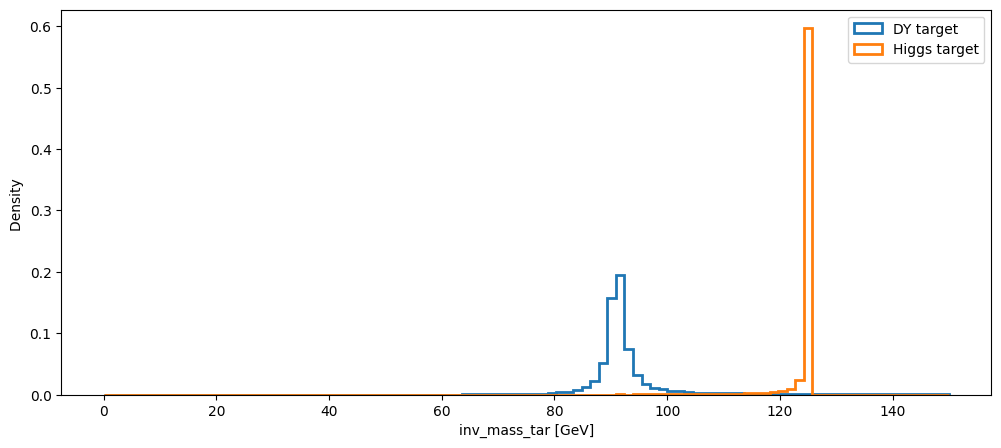

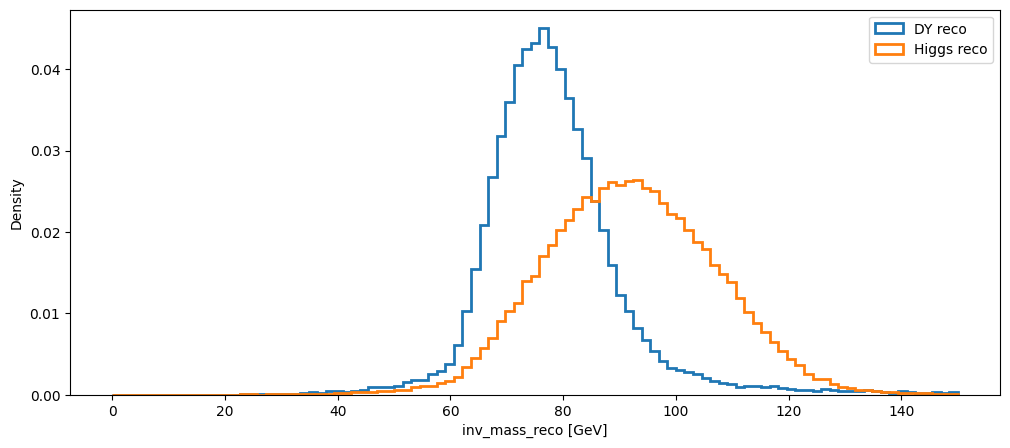

In [23]:
import numpy as np
import matplotlib.pyplot as plt

bins = np.linspace(0, 150, 100)

plt.figure(figsize=(12,5))
plt.hist(df_DY_event["inv_mass_tar"], bins=bins, histtype="step", density=True, label="DY target", linewidth = 2)
plt.hist(df_H_event["inv_mass_tar"], bins=bins, histtype="step", density=True, label="Higgs target", linewidth = 2)
plt.xlabel("inv_mass_tar [GeV]")
plt.ylabel("Density ")
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.hist(df_DY_event["inv_mass_reco"], bins=bins, histtype="step", density=True, label="DY reco",linewidth = 2)
plt.hist(df_H_event["inv_mass_reco"], bins=bins, histtype="step", density=True, label="Higgs reco",linewidth = 2)
plt.xlabel("inv_mass_reco [GeV]")
plt.ylabel("Density")
plt.legend()
plt.show()


# Model

In [24]:
import time
import torch

from torch import nn, Tensor

from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

import matplotlib.pyplot as plt

from matplotlib import cm

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [25]:
tau1_cols = [
    "tau1_logpt", "tau1_eta", "tau1_phi", "tau1_mass",
    "tau1_dxy", "tau1_dz",
    "tau1_ptCorrPNet", "tau1_rawPNetVSjet", "tau1_rawDeepTau2018v2p5VSjet",
    "tau1_charge",
    "tau1_dM_0", "tau1_dM_1", "tau1_dM_2", "tau1_dM_10", "tau1_dM_11",
    "tau1_leadTkDeltaEta", "tau1_leadTkDeltaPhi", "tau1_leadTkPtOverTauPt", 
    # "tau1_ptreco_over_ptgen",
 #   "gen_tau1_logpt"
]

tau2_cols = [
    "tau2_logpt", "tau2_eta", "tau2_phi", "tau2_mass",
    "tau2_dxy", "tau2_dz",
    "tau2_ptCorrPNet", "tau2_rawPNetVSjet", "tau2_rawDeepTau2018v2p5VSjet",
    "tau2_charge",
    "tau2_dM_0", "tau2_dM_1", "tau2_dM_2", "tau2_dM_10", "tau2_dM_11",
    "tau2_leadTkDeltaEta", "tau2_leadTkDeltaPhi", "tau2_leadTkPtOverTauPt", 
    # "tau2_ptreco_over_ptgen",
  #  "gen_tau2_logpt",
]

jet_cols = [
    "jet1_logpt", "jet1_eta", "jet1_phi", "jet1_mass",
    "jet2_logpt", "jet2_eta", "jet2_phi", "jet2_mass",
    "jet3_logpt", "jet3_eta", "jet3_phi", "jet3_mass",
]

met_cols = [
    "MET_logpt","MET_phi","MET_covXX","MET_covXY",
    "MET_covYY","MET_significance","MET_sumEt","MET_sumPtUnclustered"
]

# gen_cols = ["gen_tau1_logpt", "gen_tau2_logpt"]

# mass_cols = ["inv_mass_reco", "inv_mass_tar"]

class_col = ["class"]

df_DY_event["class"] = 0  
df_H_event["class"] = 1

In [26]:
met_cols_reduced = [
    "MET_logpt",
    "MET_phi",
    "MET_significance",
    "MET_sumEt",
]

In [27]:
train_cols = (
    tau1_cols
    + tau2_cols
    + jet_cols
    + met_cols_reduced
)

In [49]:
# Target: fattore di correzione

eps = 1e-8
for df in [df_DY_event, df_H_event]:
    df["tau1_corr"] = df["tau1_pt_gen"] / np.clip(df["tau1_pt_reco_corrPNet"], eps, None)
    df["tau2_corr"] = df["tau2_pt_gen"] / np.clip(df["tau2_pt_reco_corrPNet"], eps, None)

y_cols = ["tau1_corr", "tau2_corr"]


# Model

# 1. Balanced vs Unbalanced

In [56]:
import copy
import math
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# -----------------------
# Reproducibility
# -----------------------
def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# -----------------------
# Dataset
# -----------------------
class TabularFMDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        return self.X[i], self.y[i]


# -----------------------
# Time embedding 
# -----------------------
class FourierTimeEmbedding(nn.Module):
    def __init__(self, embed_dim=64, max_freq=10.0):
        super().__init__()
        assert embed_dim % 2 == 0
        freqs = torch.linspace(1.0, max_freq, embed_dim // 2)
        self.register_buffer("freqs", freqs)

    def forward(self, t):
        # t: (B,) in [0,1]
        # returns (B, embed_dim)
        angles = 2.0 * math.pi * t[:, None] * self.freqs[None, :]
        return torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)


# -----------------------
# Conditional velocity field v_theta(t, x_t, context)
# -----------------------
class ConditionalVelocityField(nn.Module):
    def __init__(
        self,
        x_dim: int,          # y-dim (2)
        context_dim: int,    # len(train_cols)
        hidden=(256, 256, 256),
        time_embed_dim=64,
        dropout=0.0,
    ):
        super().__init__()
        self.time_embed = FourierTimeEmbedding(embed_dim=time_embed_dim, max_freq=10.0)

        in_dim = x_dim + context_dim + time_embed_dim
        layers = []
        d = in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.SiLU()]
            if dropout > 0:
                layers += [nn.Dropout(dropout)]
            d = h
        layers += [nn.Linear(d, x_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, t, x_t, context):
        # t: (B,)
        # x_t: (B, x_dim)
        # context: (B, context_dim)
        t_emb = self.time_embed(t)
        inp = torch.cat([x_t, context, t_emb], dim=-1)
        return self.net(inp)


# -----------------------
# Flow Matching loss (linear path)
# -----------------------
def fm_loss(model, context, x1, device):
    """
    context: (B, C)
    x1: (B, x_dim)   target (scaled y, possibly log-transformed)
    """
    B, x_dim = x1.shape
    t = torch.rand(B, device=device)  # Uniform(0,1)
    x0 = torch.randn(B, x_dim, device=device)  # base N(0,I)

    x_t = (1.0 - t)[:, None] * x0 + t[:, None] * x1
    v_star = x1 - x0

    v_pred = model(t, x_t, context)
    return torch.mean((v_pred - v_star) ** 2)


# -----------------------
# Sampling: integrate ODE from t=0 to t=1
# -----------------------
@torch.no_grad()
def sample_y(model, context, n_steps=50, device="cpu"):
    """
    context: (B, C) torch.float32
    returns x1_hat: (B, x_dim)
    """
    model.eval()
    B = context.shape[0]
    x_dim = model.net[-1].out_features

    x = torch.randn(B, x_dim, device=device)  # x(t=0)
    dt = 1.0 / n_steps

    for k in range(n_steps):
        t = torch.full((B,), k * dt, device=device)
        v = model(t, x, context)
        x = x + dt * v  # Euler

    return x  # approx x(t=1)


In [57]:
def make_balanced_df(df_all, class_col="class", seed=42):
    # downsample majority class to match minority
    df0 = df_all[df_all[class_col] == 0]
    df1 = df_all[df_all[class_col] == 1]
    n = min(len(df0), len(df1))
    df0b = df0.sample(n=n, random_state=seed, replace=False)
    df1b = df1.sample(n=n, random_state=seed, replace=False)
    return pd.concat([df0b, df1b], axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)


def split_80_10_10(df, seed=42):
    df_train, df_tmp = train_test_split(df, test_size=0.20, random_state=seed, shuffle=True)
    df_val, df_test  = train_test_split(df_tmp, test_size=0.50, random_state=seed, shuffle=True)
    return df_train.reset_index(drop=True), df_val.reset_index(drop=True), df_test.reset_index(drop=True)


class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best = np.inf
        self.count = 0
        self.best_state = None

    def step(self, val_loss, model):
        improved = (self.best - val_loss) > self.min_delta
        if improved:
            self.best = val_loss
            self.count = 0
            self.best_state = copy.deepcopy(model.state_dict())
            return False  # do not stop
        else:
            self.count += 1
            return self.count >= self.patience  # stop if patience exceeded


def prepare_arrays(df_train, df_val, df_test, train_cols, y_cols, log_y=True):
    # X
    X_train = df_train[train_cols].to_numpy()
    X_val   = df_val[train_cols].to_numpy()
    X_test  = df_test[train_cols].to_numpy()

    # y
    y_train = df_train[y_cols].to_numpy()
    y_val   = df_val[y_cols].to_numpy()
    y_test  = df_test[y_cols].to_numpy()

    if log_y:
        # clip to avoid log(0)
        eps = 1e-12
        y_train = np.log(np.clip(y_train, eps, None))
        y_val   = np.log(np.clip(y_val, eps, None))
        y_test  = np.log(np.clip(y_test, eps, None))

    # standardize (fit ONLY on train)
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_s = x_scaler.fit_transform(X_train)
    X_val_s   = x_scaler.transform(X_val)
    X_test_s  = x_scaler.transform(X_test)

    y_train_s = y_scaler.fit_transform(y_train)
    y_val_s   = y_scaler.transform(y_val)
    y_test_s  = y_scaler.transform(y_test)

    return (X_train_s, X_val_s, X_test_s,
            y_train_s, y_val_s, y_test_s,
            x_scaler, y_scaler)


def train_conditional_flow_matching(
    df_all,
    train_cols,
    y_cols,
    balanced: bool,
    class_col="class",
    seed=42,
    log_y=True,
    batch_size=2048,
    hidden=(256, 256, 256),
    dropout=0.0,
    lr=2e-4,
    weight_decay=0.0,
    max_epochs=200,
    patience=15,
    min_delta=0.0,
    device=None,
):
    set_seed(seed)
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    # balanced/unbalanced
    if balanced:
        df_use = make_balanced_df(df_all, class_col=class_col, seed=seed)
    else:
        df_use = df_all.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    # split 80/10/10
    df_train, df_val, df_test = split_80_10_10(df_use, seed=seed)

    # arrays + scalers
    (Xtr, Xva, Xte,
     ytr, yva, yte,
     x_scaler, y_scaler) = prepare_arrays(df_train, df_val, df_test, train_cols, y_cols, log_y=log_y)

    train_loader = DataLoader(TabularFMDataset(Xtr, ytr), batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader   = DataLoader(TabularFMDataset(Xva, yva), batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(TabularFMDataset(Xte, yte), batch_size=batch_size, shuffle=False)

    # model
    model = ConditionalVelocityField(
        x_dim=len(y_cols),
        context_dim=len(train_cols),
        hidden=hidden,
        time_embed_dim=64,
        dropout=dropout,
    ).to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    stopper = EarlyStopping(patience=patience, min_delta=min_delta)

    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, max_epochs + 1):
        # ---- train ----
        model.train()
        tr_losses = []
        for Xb, yb in train_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)

            loss = fm_loss(model, context=Xb, x1=yb, device=device)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()

            tr_losses.append(loss.item())

        train_loss = float(np.mean(tr_losses)) if tr_losses else np.nan

        # ---- val ----
        model.eval()
        va_losses = []
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb = Xb.to(device)
                yb = yb.to(device)
                loss = fm_loss(model, context=Xb, x1=yb, device=device)
                va_losses.append(loss.item())

        val_loss = float(np.mean(va_losses)) if va_losses else np.nan

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # early stopping
        stop = stopper.step(val_loss, model)
        if stop:
            break

    # restore best
    if stopper.best_state is not None:
        model.load_state_dict(stopper.best_state)

    # final test loss (FM objective)
    model.eval()
    te_losses = []
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)
            loss = fm_loss(model, context=Xb, x1=yb, device=device)
            te_losses.append(loss.item())
    test_loss = float(np.mean(te_losses)) if te_losses else np.nan

    out = {
        "model": model,
        "history": history,
        "test_loss": test_loss,
        "x_scaler": x_scaler,
        "y_scaler": y_scaler,
        "log_y": log_y,
        "device": device,
        "df_splits": (df_train, df_val, df_test),
    }
    return out


In [58]:
# 1) unisco DY + H
df_all = pd.concat([df_DY_event, df_H_event], axis=0).reset_index(drop=True)

# 2) train UNBALANCED 
res_unbalanced = train_conditional_flow_matching(
    df_all=df_all,
    train_cols=train_cols,
    y_cols=y_cols,
    balanced=False,
    lr=2e-4,           # learning rate
    max_epochs=300,
    patience=20,       # early stopping
    batch_size=2048,
    log_y=True,
)

print("UNBALANCED test loss:", res_unbalanced["test_loss"])

# 3) train BALANCED (downsample della classe Higgs)
res_balanced = train_conditional_flow_matching(
    df_all=df_all,
    train_cols=train_cols,
    y_cols=y_cols,
    balanced=True,
    lr=2e-4,
    max_epochs=300,
    patience=20,
    batch_size=2048,
    log_y=True,
)

print("BALANCED test loss:", res_balanced["test_loss"])


UNBALANCED test loss: 1.0152897040049236
BALANCED test loss: 1.31902011235555


In [59]:
# Inference :
@torch.no_grad()
def predict_tau_corr(df, res, train_cols, y_cols, n_steps=60):
    model   = res["model"]
    device  = res["device"]
    xscaler = res["x_scaler"]
    yscaler = res["y_scaler"]
    log_y   = res["log_y"]

    X = xscaler.transform(df[train_cols].to_numpy())
    X = torch.tensor(X, dtype=torch.float32, device=device)

    y_hat_s = sample_y(model, X, n_steps=n_steps, device=device)          # scaled (and maybe log)
    y_hat   = yscaler.inverse_transform(y_hat_s.cpu().numpy())

    if log_y:
        y_hat = np.exp(y_hat)

    out = df.copy()
    out["tau1_corr_pred"] = y_hat[:, 0]
    out["tau2_corr_pred"] = y_hat[:, 1]
    return out


In [60]:
import numpy as np
import matplotlib.pyplot as plt

def pt_eta_phi_m_to_p4(pt, eta, phi, m):
    """
    Arrays -> (E, px, py, pz)
    """
    pt  = np.asarray(pt)
    eta = np.asarray(eta)
    phi = np.asarray(phi)
    m   = np.asarray(m)

    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)
    p2 = px**2 + py**2 + pz**2
    E  = np.sqrt(np.maximum(p2 + m**2, 0.0))
    return E, px, py, pz

def inv_mass_two_objects(pt1, eta1, phi1, m1, pt2, eta2, phi2, m2):
    E1, px1, py1, pz1 = pt_eta_phi_m_to_p4(pt1, eta1, phi1, m1)
    E2, px2, py2, pz2 = pt_eta_phi_m_to_p4(pt2, eta2, phi2, m2)

    E  = E1 + E2
    px = px1 + px2
    py = py1 + py2
    pz = pz1 + pz2

    m2_tot = E**2 - (px**2 + py**2 + pz**2)
    return np.sqrt(np.maximum(m2_tot, 0.0))


In [61]:
# --- su quale insieme fare i plot ---
# 1. tutto df_all: 
# df_plot = df_all.copy()

# 2. plot solo test set (per evitare bias):
df_train_u, df_val_u, df_test_u = res_unbalanced["df_splits"]
df_plot = df_test_u.copy()

# 1) predizioni UNBALANCED
df_pred_u = predict_tau_corr(df_plot, res_unbalanced, train_cols, y_cols, n_steps=60)
df_plot["tau1_corr_pred_unbal"] = df_pred_u["tau1_corr_pred"].values
df_plot["tau2_corr_pred_unbal"] = df_pred_u["tau2_corr_pred"].values

# 2) predizioni BALANCED
df_pred_b = predict_tau_corr(df_plot, res_balanced, train_cols, y_cols, n_steps=60)
df_plot["tau1_corr_pred_bal"] = df_pred_b["tau1_corr_pred"].values
df_plot["tau2_corr_pred_bal"] = df_pred_b["tau2_corr_pred"].values

# 3) pT corretti
df_plot["tau1_pt_FM_unbal"] = df_plot["tau1_pt_reco_corrPNet"] * df_plot["tau1_corr_pred_unbal"]
df_plot["tau2_pt_FM_unbal"] = df_plot["tau2_pt_reco_corrPNet"] * df_plot["tau2_corr_pred_unbal"]

df_plot["tau1_pt_FM_bal"] = df_plot["tau1_pt_reco_corrPNet"] * df_plot["tau1_corr_pred_bal"]
df_plot["tau2_pt_FM_bal"] = df_plot["tau2_pt_reco_corrPNet"] * df_plot["tau2_corr_pred_bal"]

# 4) masse invarianti corrette
df_plot["inv_mass_FM_unbal"] = inv_mass_two_objects(
    df_plot["tau1_pt_FM_unbal"], df_plot["tau1_eta"], df_plot["tau1_phi"], df_plot["tau1_mass"],
    df_plot["tau2_pt_FM_unbal"], df_plot["tau2_eta"], df_plot["tau2_phi"], df_plot["tau2_mass"],
)

df_plot["inv_mass_FM_bal"] = inv_mass_two_objects(
    df_plot["tau1_pt_FM_bal"], df_plot["tau1_eta"], df_plot["tau1_phi"], df_plot["tau1_mass"],
    df_plot["tau2_pt_FM_bal"], df_plot["tau2_eta"], df_plot["tau2_phi"], df_plot["tau2_mass"],
)


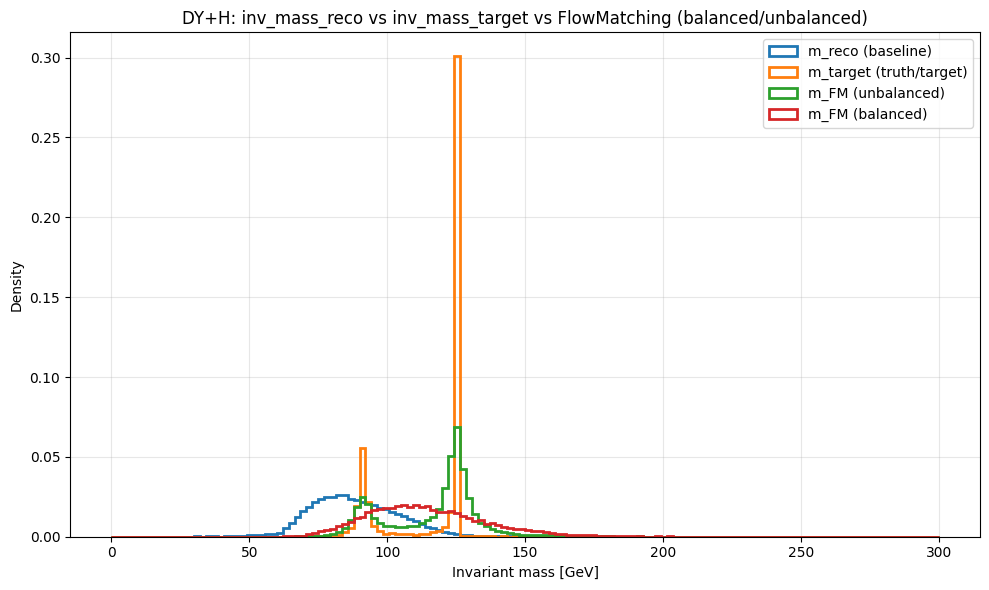

In [62]:
def plot_mass_comparison(df, bins=120, mass_range=(0, 300), title="Invariant mass comparison"):
    m_reco = df["inv_mass_reco"].values
    m_tar  = df["inv_mass_tar"].values
    m_u    = df["inv_mass_FM_unbal"].values
    m_b    = df["inv_mass_FM_bal"].values

    plt.figure(figsize=(10, 6))
    plt.hist(m_reco, bins=bins, range=mass_range, histtype="step", density=True, linewidth=2, label="m_reco (baseline)")
    plt.hist(m_tar,  bins=bins, range=mass_range, histtype="step", density=True, linewidth=2, label="m_target (truth/target)")
    plt.hist(m_u,    bins=bins, range=mass_range, histtype="step", density=True, linewidth=2, label="m_FM (unbalanced)")
    plt.hist(m_b,    bins=bins, range=mass_range, histtype="step", density=True, linewidth=2, label="m_FM (balanced)")

    plt.xlabel("Invariant mass [GeV]")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_mass_comparison(
    df_plot,
    bins=140,
    mass_range=(0, 300),
    title="DY+H: inv_mass_reco vs inv_mass_target vs FlowMatching (balanced/unbalanced)"
)


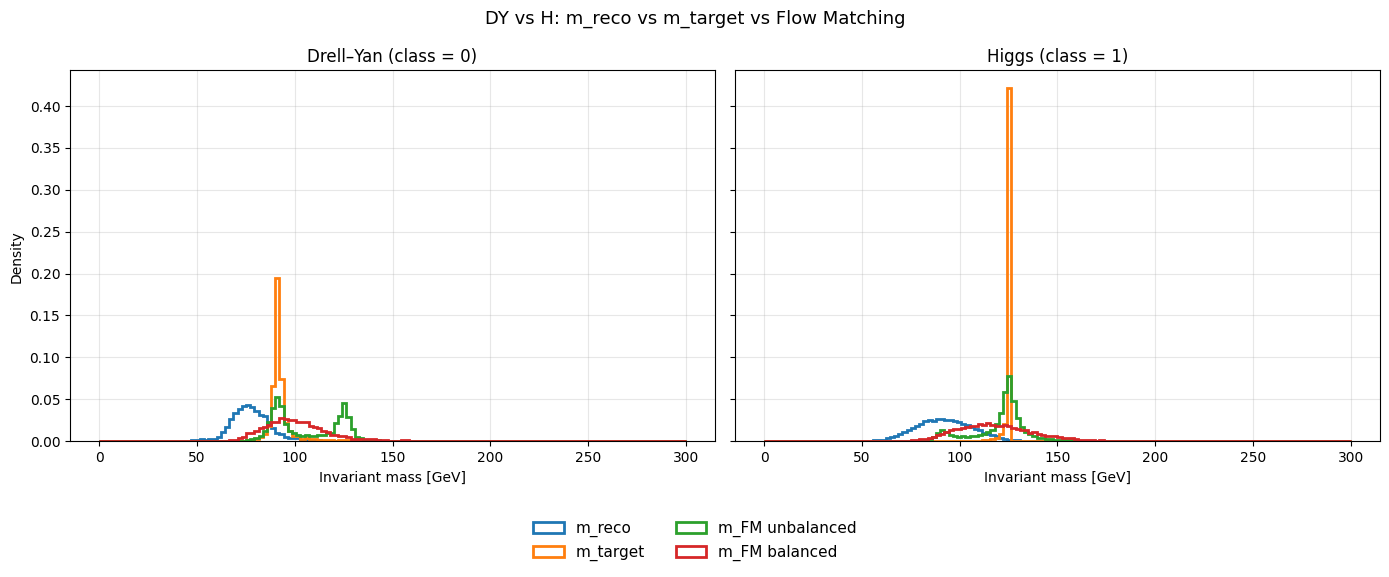

In [65]:
def plot_mass_comparison_by_class(
    df,
    bins=140,
    mass_range=(0, 300),
    class_col="class",
    title="Invariant mass: DY vs H (baseline/target/FM balanced/unbalanced)"
):
    df_dy = df[df[class_col] == 0]
    df_h  = df[df[class_col] == 1]

    def get_arrays(d):
        return (
            d["inv_mass_reco"].values,
            d["inv_mass_tar"].values,
            d["inv_mass_FM_unbal"].values,
            d["inv_mass_FM_bal"].values,
        )

    m_reco_dy, m_tar_dy, m_u_dy, m_b_dy = get_arrays(df_dy)
    m_reco_h,  m_tar_h,  m_u_h,  m_b_h  = get_arrays(df_h)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    labels = [
        "m_reco",
        "m_target",
        "m_FM unbalanced",
        "m_FM balanced",
    ]

    # --- DY ---
    axes[0].hist(m_reco_dy, bins=bins, range=mass_range, histtype="step", density=True, lw=2, label=labels[0])
    axes[0].hist(m_tar_dy,  bins=bins, range=mass_range, histtype="step", density=True, lw=2, label=labels[1])
    axes[0].hist(m_u_dy,    bins=bins, range=mass_range, histtype="step", density=True, lw=2, label=labels[2])
    axes[0].hist(m_b_dy,    bins=bins, range=mass_range, histtype="step", density=True, lw=2, label=labels[3])
    axes[0].set_title("Drell–Yan (class = 0)")
    axes[0].set_xlabel("Invariant mass [GeV]")
    axes[0].set_ylabel("Density")
    axes[0].grid(alpha=0.3)

    # --- Higgs ---
    axes[1].hist(m_reco_h, bins=bins, range=mass_range, histtype="step", density=True, lw=2)
    axes[1].hist(m_tar_h,  bins=bins, range=mass_range, histtype="step", density=True, lw=2)
    axes[1].hist(m_u_h,    bins=bins, range=mass_range, histtype="step", density=True, lw=2)
    axes[1].hist(m_b_h,    bins=bins, range=mass_range, histtype="step", density=True, lw=2)
    axes[1].set_title("Higgs (class = 1)")
    axes[1].set_xlabel("Invariant mass [GeV]")
    axes[1].grid(alpha=0.3)

    # --- legenda globale sotto ---
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=2,              # due colonne → due righe
        frameon=False,
        fontsize=11,
        bbox_to_anchor=(0.5, -0.15)
    )

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


plot_mass_comparison_by_class(
    df_plot,
    bins=140,
    mass_range=(0, 300),
    class_col="class",
    title="DY vs H: m_reco vs m_target vs Flow Matching"
)



In [68]:
# Quantitativamente :
# S/B 
import numpy as np
from scipy.stats import norm

def fit_gaussian_peak(masses):
    """
    Fit gaussiano semplice → mu, sigma
    """
    mu, sigma = norm.fit(masses)
    return mu, sigma


def compute_S_over_B(
    df,
    mass_col,
    class_col="class",
    sigma_window=3.0
):
    """
    class: 1 = Higgs, 0 = DY 
    """
    # Higgs only -> stima mu, sigma
    m_h = df[df[class_col] == 1][mass_col].values
    mu, sigma = fit_gaussian_peak(m_h)

    low  = mu - sigma_window * sigma
    high = mu + sigma_window * sigma

    # counts in window
    S = np.sum((m_h >= low) & (m_h <= high))
    m_dy = df[df[class_col] == 0][mass_col].values
    B = np.sum((m_dy >= low) & (m_dy <= high))

    return {
        "mu": mu,
        "sigma": sigma,
        "S": S,
        "B": B,
        "S_over_B": S / B if B > 0 else np.inf
    }


In [69]:
sb_reco = compute_S_over_B(df_plot, "inv_mass_reco")
sb_unbal = compute_S_over_B(df_plot, "inv_mass_FM_unbal")
sb_bal = compute_S_over_B(df_plot, "inv_mass_FM_bal")

sb_reco, sb_unbal, sb_bal


({'mu': np.float32(92.11793),
  'sigma': np.float32(15.073127),
  'S': np.int64(12730),
  'B': np.int64(5048),
  'S_over_B': np.float64(2.5217908082408873)},
 {'mu': np.float64(120.39317094445445),
  'sigma': np.float64(15.341281985297801),
  'S': np.int64(12699),
  'B': np.int64(5053),
  'S_over_B': np.float64(2.5131604987136353)},
 {'mu': np.float64(118.97949742999164),
  'sigma': np.float64(21.156713046725297),
  'S': np.int64(12691),
  'B': np.int64(5089),
  'S_over_B': np.float64(2.4938101788170566)})

In [70]:
# KL divergence:

def compute_KL_divergence(
    df,
    mass_col,
    class_col="class",
    bins=120,
    mass_range=(0, 300),
    eps=1e-12
):
    m_h  = df[df[class_col] == 1][mass_col].values
    m_dy = df[df[class_col] == 0][mass_col].values

    p_h, bin_edges = np.histogram(m_h, bins=bins, range=mass_range, density=True)
    p_dy, _        = np.histogram(m_dy, bins=bins, range=mass_range, density=True)

    # evita log(0)
    p_h  = p_h  + eps
    p_dy = p_dy + eps

    kl = np.sum(p_h * np.log(p_h / p_dy))
    return kl

kl_reco = compute_KL_divergence(df_plot, "inv_mass_reco")
kl_unbal = compute_KL_divergence(df_plot, "inv_mass_FM_unbal")
kl_bal = compute_KL_divergence(df_plot, "inv_mass_FM_bal")

kl_reco, kl_unbal, kl_bal


(np.float64(0.2866043980558534),
 np.float64(0.15342931458796988),
 np.float64(0.18391669617416023))

In [71]:
# EMD
from scipy.stats import wasserstein_distance

def compute_EMD(
    df,
    mass_col,
    class_col="class"
):
    m_h  = df[df[class_col] == 1][mass_col].values
    m_dy = df[df[class_col] == 0][mass_col].values
    return wasserstein_distance(m_h, m_dy)

emd_reco = compute_EMD(df_plot, "inv_mass_reco")
emd_unbal = compute_EMD(df_plot, "inv_mass_FM_unbal")
emd_bal = compute_EMD(df_plot, "inv_mass_FM_bal")

emd_reco, emd_unbal, emd_bal


(np.float64(14.140873507900642),
 np.float64(14.604512213271342),
 np.float64(17.06674764719212))

In [72]:
import pandas as pd

results = pd.DataFrame({
    "Method": ["Baseline reco", "FM unbalanced", "FM balanced"],
    "S/B (±3σ)": [
        sb_reco["S_over_B"],
        sb_unbal["S_over_B"],
        sb_bal["S_over_B"]
    ],
    "KL divergence": [
        kl_reco,
        kl_unbal,
        kl_bal
    ],
    "EMD": [
        emd_reco,
        emd_unbal,
        emd_bal
    ]
})

results


,Method,S/B (±3σ),KL divergence,EMD
0,Baseline reco,2.521791,0.286604,14.140874
1,FM unbalanced,2.513160,0.153429,14.604512
2,FM balanced,2.493810,0.183917,17.066748


- To sum up:
  1. Con training balanced, la distanzatra  DY e H in massa aumenta (KL)
  2. FM unbalanced riduce KL, nessun guadagno in S/B, EMD migliore ma marginalmente

In [73]:
def mass_mae_rmse(df, mass_pred_col, mass_tar_col="inv_mass_tar", class_col="class", which_class=1):
    d = df[df[class_col] == which_class]
    err = d[mass_pred_col].values - d[mass_tar_col].values
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err**2))
    return mae, rmse

mae_reco, rmse_reco = mass_mae_rmse(df_plot, "inv_mass_reco")
mae_u, rmse_u       = mass_mae_rmse(df_plot, "inv_mass_FM_unbal")
mae_b, rmse_b       = mass_mae_rmse(df_plot, "inv_mass_FM_bal")

(mae_reco, rmse_reco), (mae_u, rmse_u), (mae_b, rmse_b)


((np.float64(32.50273168506672), np.float64(35.61400937350881)),
 (np.float64(10.471566938321109), np.float64(15.951948941081989)),
 (np.float64(17.382626893876356), np.float64(21.838235046856756)))

In [74]:
import pandas as pd

df_mae_rmse = pd.DataFrame({
    "Method": ["Baseline reco", "FM unbalanced", "FM balanced"],
    "MAE_H [GeV]": [
        mae_reco,
        mae_u,
        mae_b
    ],
    "RMSE_H [GeV]": [
        rmse_reco,
        rmse_u,
        rmse_b
    ]
})

df_mae_rmse.round(3)



,Method,MAE_H [GeV],RMSE_H [GeV]
0,Baseline reco,32.503,35.614
1,FM unbalanced,10.472,15.952
2,FM balanced,17.383,21.838


# 2. Cut on Tails (m_reco in (80-140) GeV)

In [75]:
# definizione cut
m_min, m_max = 80.0, 140.0

df_all_cut = df_all[
    (df_all["inv_mass_tar"] >= m_min) &
    (df_all["inv_mass_tar"] <= m_max)
].reset_index(drop=True)

print(f"Eventi pre-cut:  {len(df_all)}")
print(f"Eventi post-cut: {len(df_all_cut)}")


Eventi pre-cut:  179459
Eventi post-cut: 176718


In [77]:
res_unbalanced_cut = train_conditional_flow_matching(
    df_all=df_all_cut,
    train_cols=train_cols,
    y_cols=y_cols,
    balanced=False,          # UNBALANCED 
    lr=2e-4,
    max_epochs=300,
    patience=20,
    batch_size=2048,
    log_y=True,
)


In [78]:
# predizioni modello PRE-CUT
df_pred_pre = predict_tau_corr(
    df_plot,
    res_unbalanced,
    train_cols,
    y_cols,
    n_steps=60
)

# predizioni modello POST-CUT
df_pred_cut = predict_tau_corr(
    df_plot,
    res_unbalanced_cut,
    train_cols,
    y_cols,
    n_steps=60
)


In [79]:
df_plot["inv_mass_FM_pre"] = inv_mass_two_objects(
    df_plot["tau1_pt_reco_corrPNet"] * df_pred_pre["tau1_corr_pred"],
    df_plot["tau1_eta"], df_plot["tau1_phi"], df_plot["tau1_mass"],
    df_plot["tau2_pt_reco_corrPNet"] * df_pred_pre["tau2_corr_pred"],
    df_plot["tau2_eta"], df_plot["tau2_phi"], df_plot["tau2_mass"],
)

df_plot["inv_mass_FM_cut"] = inv_mass_two_objects(
    df_plot["tau1_pt_reco_corrPNet"] * df_pred_cut["tau1_corr_pred"],
    df_plot["tau1_eta"], df_plot["tau1_phi"], df_plot["tau1_mass"],
    df_plot["tau2_pt_reco_corrPNet"] * df_pred_cut["tau2_corr_pred"],
    df_plot["tau2_eta"], df_plot["tau2_phi"], df_plot["tau2_mass"],
)


In [80]:
mae_pre, rmse_pre = mass_mae_rmse(df_plot, "inv_mass_FM_pre")
mae_cut, rmse_cut = mass_mae_rmse(df_plot, "inv_mass_FM_cut")

pd.DataFrame({
    "Model": ["FM unbalanced (pre-cut)", "FM unbalanced (post-cut)"],
    "MAE_H [GeV]": [mae_pre, mae_cut],
    "RMSE_H [GeV]": [rmse_pre, rmse_cut],
}).round(3)

kl_pre  = compute_KL_divergence(df_plot, "inv_mass_FM_pre")
kl_cut  = compute_KL_divergence(df_plot, "inv_mass_FM_cut")

emd_pre = compute_EMD(df_plot, "inv_mass_FM_pre")
emd_cut = compute_EMD(df_plot, "inv_mass_FM_cut")

pd.DataFrame({
    "Model": ["FM pre-cut", "FM post-cut"],
    "KL divergence": [kl_pre, kl_cut],
    "EMD": [emd_pre, emd_cut],
}).round(3)

,Model,KL divergence,EMD
0,FM pre-cut,0.159,14.499
1,FM post-cut,0.152,13.323


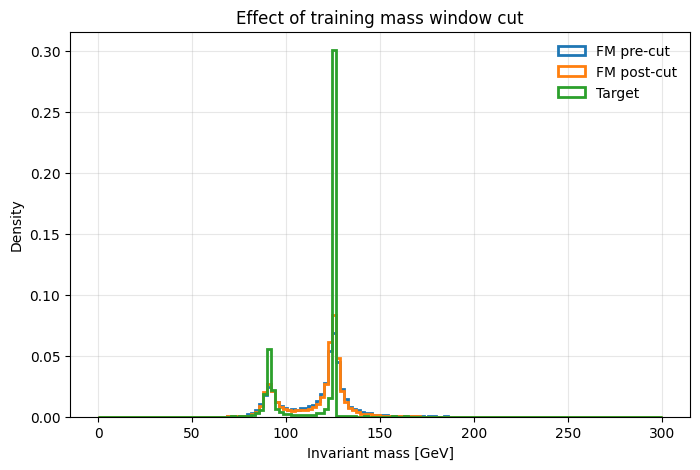

In [81]:
plt.figure(figsize=(8,5))
plt.hist(df_plot["inv_mass_FM_pre"], bins=140, range=(0,300),
         histtype="step", density=True, lw=2, label="FM pre-cut")
plt.hist(df_plot["inv_mass_FM_cut"], bins=140, range=(0,300),
         histtype="step", density=True, lw=2, label="FM post-cut")
plt.hist(df_plot["inv_mass_tar"], bins=140, range=(0,300),
         histtype="step", density=True, lw=2, label="Target")

plt.xlabel("Invariant mass [GeV]")
plt.ylabel("Density")
plt.legend(frameon=False)
plt.title("Effect of training mass window cut")
plt.grid(alpha=0.3)
plt.show()


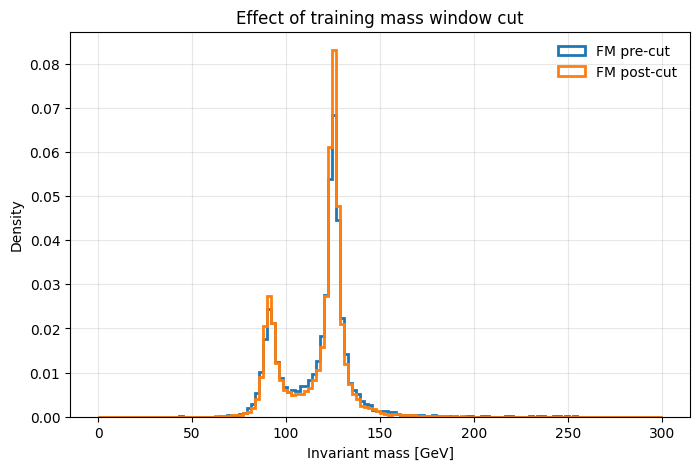

In [82]:
plt.figure(figsize=(8,5))
plt.hist(df_plot["inv_mass_FM_pre"], bins=140, range=(0,300),
         histtype="step", density=True, lw=2, label="FM pre-cut")
plt.hist(df_plot["inv_mass_FM_cut"], bins=140, range=(0,300),
         histtype="step", density=True, lw=2, label="FM post-cut")
#plt.hist(df_plot["inv_mass_tar"], bins=140, range=(0,300),
#         histtype="step", density=True, lw=2, label="Target")

plt.xlabel("Invariant mass [GeV]")
plt.ylabel("Density")
plt.legend(frameon=False)
plt.title("Effect of training mass window cut")
plt.grid(alpha=0.3)
plt.show()

In [83]:
def mass_mae_rmse(
    df,
    mass_pred_col,
    mass_tar_col="inv_mass_tar",
    class_col="class",
    which_class=1
):
    d = df[df[class_col] == which_class]
    err = d[mass_pred_col].values - d[mass_tar_col].values
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err**2))
    return mae, rmse


# --- calcolo ---
mae_pre, rmse_pre = mass_mae_rmse(df_plot, "inv_mass_FM_pre")
mae_cut, rmse_cut = mass_mae_rmse(df_plot, "inv_mass_FM_cut")

# --- tabella finale ---
df_mae_rmse_prepost = pd.DataFrame({
    "Model": ["FM unbalanced (pre-cut)", "FM unbalanced (post-cut)"],
    "MAE_H [GeV]": [mae_pre, mae_cut],
    "RMSE_H [GeV]": [rmse_pre, rmse_cut],
})

df_mae_rmse_prepost.round(3)


,Model,MAE_H [GeV],RMSE_H [GeV]
0,FM unbalanced (pre-cut),10.443,15.943
1,FM unbalanced (post-cut),9.506,14.965


- To sum up:
  1. Il modello post-cut è meno orientato alla separazione globale DY–H
  2. ma più accurato nella ricostruzione evento-per-evento della massa Higgs

# 3. Flat Samples + Fine Tuning

In [84]:
# --------- Apro i samples flat  ------------
VBF = np.load("VBFtoXto2Tau_M-30to300.npz")

print(VBF.files)

# check :
print("x_taus:", VBF["x_taus"].shape)
print("x_taus_gen", VBF["x_gen"].shape)
print("x_met :", VBF["x_met"].shape)
print("x_jets:", VBF["x_jets"].shape)
print("m_gen :", VBF["m_gen"].shape)

['x_taus', 'x_tauprod', 'x_met', 'x_jets', 'x_neutrinos', 'x_gen', 'm_vis', 'm_vis_ptcorr', 'm_gen', 'm_gen_pt_vis_angles', 'm_vis_ptcorr_plus_nu', 'm_tauprod_nu', 'm_vis_nu_vis', 'm_fastmtt']
x_taus: (632014, 2, 18)
x_taus_gen (632014, 2, 4)
x_met : (632014, 1, 8)
x_jets: (632014, 3, 4)
m_gen : (632014,)


In [85]:
taus = VBF["x_taus"]        # shape (N, 2, 18)
# tauprod = VBF["x_tauprod"]  # shape (N, 10, 10)
tau_gen = VBF["x_gen"]       # shape (N, 2,  4)
met = VBF["x_met"]          # shape (N, 1, 8)
jets = VBF["x_jets"]        # shape (N, 3, 4)

m_vis_ptcorr = VBF["m_vis_ptcorr"]   # (N,)    --> La uso come m_reco
m_target = VBF["m_gen"]              # (N,)
m_vis = VBF["m_vis"]                 # (N,)
m_fastmtt = VBF["m_fastmtt"]         # (N,)


tau_features = [
    "logpt", "eta", "phi", "mass", "dxy", "dz",
    "ptCorrPNet", "rawPNetVSjet", "rawDeepTau2018v2p5VSjet",
    "charge",
    "dM_0", "dM_1", "dM_2", "dM_10", "dM_11",
    "leadTkDeltaEta", "leadTkDeltaPhi", "leadTkPtOverTauPt"
]

gen_tau_features = ["pt", "eta", "phi", "mass"]  # x_gen


import pandas as pd

N = taus.shape[0]

df = {}

# ---------- TAU 1 & TAU 2 ----------
for itau in [0, 1]:
    prefix = f"tau{itau+1}_"
    for i, feat in enumerate(tau_features):
        df[prefix + feat] = taus[:, itau, i]

# ---------- TAU GEN (TAU 1 & TAU 2) ----------
for itau in [0, 1]:
    prefix = f"gen_tau{itau+1}_"
    for i, feat in enumerate(gen_tau_features):
        df[prefix + feat] = tau_gen[:, itau, i]

# ---------- MET ----------
met_features = [
    "MET_logpt", "MET_phi", "MET_covXX", "MET_covXY",
    "MET_covYY", "MET_significance", "MET_sumEt", "MET_sumPtUnclustered"
]

for i, feat in enumerate(met_features):
    df[feat] = met[:, 0, i]

# ---------- JETS (3 jets) ----------
jet_features = ["logpt", "eta", "phi", "mass"]

for j in range(3):
    for i, feat in enumerate(jet_features):
        df[f"jet{j+1}_{feat}"] = jets[:, j, i]

# ---------- MASSE ----------
df["m_vis"]         = m_vis
df["m_vis_ptcorr"]  = m_vis_ptcorr
df["m_fastmtt"]     = m_fastmtt
df["m_gen"]         = m_target


df_flat = pd.DataFrame(df)

print(df_flat.shape)
df_flat.head()

(632014, 68)


,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,jet2_phi,jet2_mass,jet3_logpt,jet3_eta,jet3_phi,jet3_mass,m_vis,m_vis_ptcorr,m_fastmtt,m_gen
0,4.200094,1.643799,2.515137,2.949219,0.634277,5.184814,1.001953,0.999512,-1.000000,-1.0,...,-1.327881,5.281250,2.880777,1.763184,-0.800903,3.589844,24.438859,27.647144,33.020302,47.239086
1,5.548124,-1.767334,-2.027832,0.829102,-0.015457,-0.012412,1.021484,0.999512,0.989258,-1.0,...,1.614990,10.671875,2.833213,-0.185181,2.087402,3.179688,85.437739,93.784651,109.942673,106.047752
2,3.746890,-0.771606,2.914062,1.334961,0.001616,-0.001660,0.996582,0.883789,0.977051,1.0,...,0.796753,6.765625,3.711283,1.373779,2.641602,7.281250,61.325864,60.001639,83.316399,77.556129
3,3.882379,-1.166748,-0.862671,0.836914,-0.000545,0.000682,0.957031,0.780762,0.909668,1.0,...,2.308594,4.167969,3.327730,-2.611816,2.785645,4.589844,109.263026,97.097534,148.204529,102.891235
4,3.899770,-0.819580,-2.420410,1.075195,0.001864,0.001069,1.448242,0.933105,0.953125,1.0,...,-2.422363,6.937500,3.800393,1.051758,2.386719,6.730469,104.564076,127.417169,143.905762,133.224426


In [86]:
df_flat["gen_tau1_logpt"] = np.log(np.clip(tau_gen[:, 0, 0], 1e-6, None))
df_flat["gen_tau2_logpt"] = np.log(np.clip(tau_gen[:, 1, 0], 1e-6, None))

log_pt_min = np.log(30.0)   # ~3.401

mask_pt = (df_flat["tau1_logpt"] > log_pt_min) & (df_flat["tau2_logpt"] > log_pt_min)

print("Eventi totali:", len(df_flat))
print("Eventi che passano pT>30 GeV (in log):", mask_pt.sum())

df_sel_flat = df_flat[mask_pt].copy()

df_sel_flat["tau1_ptreco"] = np.exp(df_sel_flat["tau1_logpt"])
df_sel_flat["tau2_ptreco"] = np.exp(df_sel_flat["tau2_logpt"])

df_sel_flat["tau1_pt_reco_corrPNet"] = df_sel_flat["tau1_ptreco"] * df_sel_flat["tau1_ptCorrPNet"]
df_sel_flat["tau2_pt_reco_corrPNet"] = df_sel_flat["tau2_ptreco"] * df_sel_flat["tau2_ptCorrPNet"]
df_sel_flat

Eventi totali: 632014
Eventi che passano pT>30 GeV (in log): 394047


,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,m_vis,m_vis_ptcorr,m_fastmtt,m_gen,gen_tau1_logpt,gen_tau2_logpt,tau1_ptreco,tau2_ptreco,tau1_pt_reco_corrPNet,tau2_pt_reco_corrPNet
1,5.548124,-1.767334,-2.027832,0.829102,-0.015457,-0.012412,1.021484,0.999512,0.989258,-1.0,...,85.437739,93.784651,109.942673,106.047752,5.659482,4.324132,256.755389,56.138509,262.271618,66.225898
4,3.899770,-0.819580,-2.420410,1.075195,0.001864,0.001069,1.448242,0.933105,0.953125,1.0,...,104.564076,127.417169,143.905762,133.224426,4.317488,3.562465,49.391065,32.726376,71.530225,33.557319
7,4.752875,-0.372742,-3.123535,1.243164,-0.006924,-0.005308,1.016602,0.999512,0.999512,-1.0,...,179.161750,182.135892,245.033875,275.803833,4.822296,4.734003,115.917106,51.630252,117.841511,52.487394
8,3.785749,-0.706299,1.264404,0.820801,0.001562,-0.005122,1.020508,0.997070,0.999512,1.0,...,58.791301,59.737181,78.706543,70.577286,4.077538,3.778491,44.068653,39.733000,44.972405,40.198621
11,4.063381,-2.416992,0.866211,0.790527,-0.000340,0.002485,1.047852,0.875488,0.941406,1.0,...,165.567559,168.653555,259.882599,269.511292,4.069027,4.497028,58.170638,33.668525,60.954193,33.339731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
632009,4.799636,-1.569092,2.992188,0.139526,-0.000405,0.001151,1.018555,0.999023,0.975586,-1.0,...,66.710782,69.521614,85.153633,81.033844,5.049856,3.823192,121.466182,39.515781,123.719949,42.139876
632010,4.394889,-1.463867,-1.856689,1.301758,-0.009041,0.014961,1.169922,0.930176,0.878906,1.0,...,139.302899,143.166716,218.654175,264.772156,4.751433,5.053056,81.035625,61.770415,94.805351,55.768309
632011,4.144735,0.811768,-0.025539,0.139526,0.000309,0.001976,1.064453,0.985352,0.997559,-1.0,...,58.390797,57.425191,71.106628,74.561821,4.551242,3.901973,63.100889,46.598283,67.167939,42.184188
632012,4.284923,-1.029297,3.136719,0.895020,-0.001932,0.000072,1.020508,0.998535,0.999512,-1.0,...,117.331283,127.608025,150.473145,203.232407,5.056246,4.477337,72.596962,63.739941,74.085767,73.886045


In [87]:
# tau ID

df_sel_flat_valid = df_sel_flat[
    (df_sel_flat["tau1_rawPNetVSjet"] != -1) &
    (df_sel_flat["tau2_rawPNetVSjet"] != -1)
].copy()

print("DY valid events =", len(df_sel_flat_valid))

# Soglia al working point 90% :
def find_threshold_for_efficiency(thresholds, efficiencies, target_eff=0.90):
    """
    Trova la soglia il cui valore di efficienza è più vicino a target_eff.
    """
    idx = np.argmin(np.abs(efficiencies - target_eff))
    return thresholds[idx], efficiencies[idx]

target_eff = 0.90

vals_tau1 = df_sel_flat_valid["tau1_rawPNetVSjet"].values
thresholds_tau1 = np.sort(np.unique(vals_tau1))

vals_tau2 = df_sel_flat_valid["tau2_rawPNetVSjet"].values
thresholds_tau2 = np.sort(np.unique(vals_tau2))

# efficienza: P(rawPNet > thr)
eff_tau1 = np.array([
    np.mean(vals_tau1 > thr) for thr in thresholds_tau1
])

thr_tau1, eff_at_thr_tau1 = find_threshold_for_efficiency(
    thresholds_tau1, eff_tau1, target_eff
)

eff_tau2 = np.array([
    np.mean(vals_tau2 > thr) for thr in thresholds_tau2
])

thr_tau2, eff_at_thr_tau2 = find_threshold_for_efficiency(
    thresholds_tau2, eff_tau2, target_eff
)

# Applico le soglie event - level : 
mask_tau1 = df_sel_flat_valid["tau1_rawPNetVSjet"] > thr_tau1
mask_tau2 = df_sel_flat_valid["tau2_rawPNetVSjet"] > thr_tau2
mask_event  = mask_tau1 & mask_tau2

df_sel_tauID = df_sel_flat_valid[mask_event].copy()

# efficienza event-level 
eff_event = mask_event.mean() if len(df_sel_flat_valid) > 0 else float("nan")

print("Efficienze con soglie (event-level AND):")
print(f"  eventi (tau1 & tau2): {eff_event:.4f}")

df_flat_event = df_sel_tauID.copy()
df_flat_event

DY valid events = 391777
Efficienze con soglie (event-level AND):
  eventi (tau1 & tau2): 0.8129


,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,m_vis,m_vis_ptcorr,m_fastmtt,m_gen,gen_tau1_logpt,gen_tau2_logpt,tau1_ptreco,tau2_ptreco,tau1_pt_reco_corrPNet,tau2_pt_reco_corrPNet
1,5.548124,-1.767334,-2.027832,0.829102,-0.015457,-0.012412,1.021484,0.999512,0.989258,-1.0,...,85.437739,93.784651,109.942673,106.047752,5.659482,4.324132,256.755389,56.138509,262.271618,66.225898
4,3.899770,-0.819580,-2.420410,1.075195,0.001864,0.001069,1.448242,0.933105,0.953125,1.0,...,104.564076,127.417169,143.905762,133.224426,4.317488,3.562465,49.391065,32.726376,71.530225,33.557319
7,4.752875,-0.372742,-3.123535,1.243164,-0.006924,-0.005308,1.016602,0.999512,0.999512,-1.0,...,179.161750,182.135892,245.033875,275.803833,4.822296,4.734003,115.917106,51.630252,117.841511,52.487394
8,3.785749,-0.706299,1.264404,0.820801,0.001562,-0.005122,1.020508,0.997070,0.999512,1.0,...,58.791301,59.737181,78.706543,70.577286,4.077538,3.778491,44.068653,39.733000,44.972405,40.198621
11,4.063381,-2.416992,0.866211,0.790527,-0.000340,0.002485,1.047852,0.875488,0.941406,1.0,...,165.567559,168.653555,259.882599,269.511292,4.069027,4.497028,58.170638,33.668525,60.954193,33.339731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
632009,4.799636,-1.569092,2.992188,0.139526,-0.000405,0.001151,1.018555,0.999023,0.975586,-1.0,...,66.710782,69.521614,85.153633,81.033844,5.049856,3.823192,121.466182,39.515781,123.719949,42.139876
632010,4.394889,-1.463867,-1.856689,1.301758,-0.009041,0.014961,1.169922,0.930176,0.878906,1.0,...,139.302899,143.166716,218.654175,264.772156,4.751433,5.053056,81.035625,61.770415,94.805351,55.768309
632011,4.144735,0.811768,-0.025539,0.139526,0.000309,0.001976,1.064453,0.985352,0.997559,-1.0,...,58.390797,57.425191,71.106628,74.561821,4.551242,3.901973,63.100889,46.598283,67.167939,42.184188
632012,4.284923,-1.029297,3.136719,0.895020,-0.001932,0.000072,1.020508,0.998535,0.999512,-1.0,...,117.331283,127.608025,150.473145,203.232407,5.056246,4.477337,72.596962,63.739941,74.085767,73.886045


Before cut: 318494
After cut: 124121


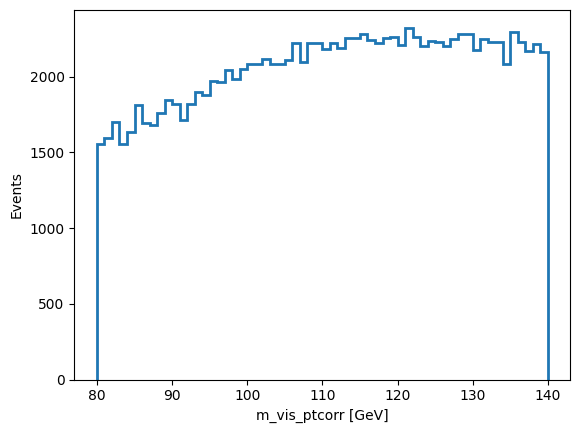

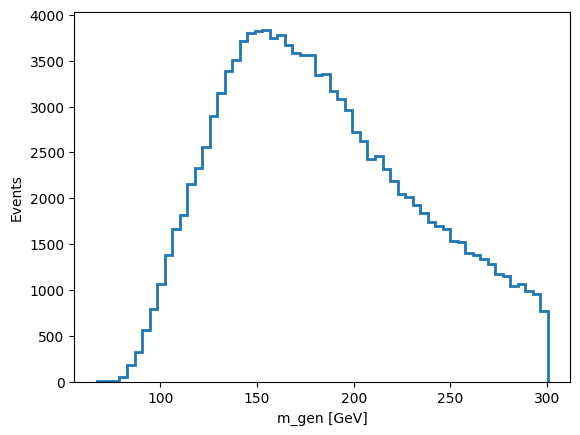

In [88]:
# taglio in massa -> su m_vis_ptcorr
print("Before cut:", len(df_flat_event))

df_flat_cut = df_flat_event[
    (df_flat_event["m_vis_ptcorr"] >= 80.0) &
    (df_flat_event["m_vis_ptcorr"] <= 140.0)
].copy()

print("After cut:", len(df_flat_cut))

# just checking 
import matplotlib.pyplot as plt

plt.hist(df_flat_cut["m_vis_ptcorr"], bins=60, histtype = 'step', linewidth = 2, density = False)   # -> Me lo aspetto quasi piatto 
plt.xlabel("m_vis_ptcorr [GeV]")
plt.ylabel("Events")
plt.show()


plt.hist(df_flat_cut["m_gen"], bins=60, histtype = 'step', linewidth = 2, density = False)
plt.xlabel("m_gen [GeV]")
plt.ylabel("Events")
plt.show()

In [89]:
# Preparazione per training 

eps = 1e-8

# Li rinomino coerentemente con il precedente modello :
df_flat_cut["tau1_pt_gen"] = df_flat_cut["gen_tau1_pt"]
df_flat_cut["tau2_pt_gen"] = df_flat_cut["gen_tau2_pt"]

# --- target: fattore di correzione ---
df_flat_cut["tau1_corr"] = df_flat_cut["tau1_pt_gen"] / np.clip(df_flat_cut["tau1_pt_reco_corrPNet"], eps, None)
df_flat_cut["tau2_corr"] = df_flat_cut["tau2_pt_gen"] / np.clip(df_flat_cut["tau2_pt_reco_corrPNet"], eps, None)

y_cols = ["tau1_corr", "tau2_corr"]

In [90]:
missing = [c for c in train_cols + y_cols if c not in df_flat_cut.columns]
print("Missing columns:", missing)
print("N train cols:", len(train_cols))
print("df_flat_cut shape:", df_flat_cut.shape)

Missing columns: []
N train cols: 52
df_flat_cut shape: (124121, 78)


In [91]:
# stesso setup di prima
res_flat_pretrain = train_conditional_flow_matching(
    df_all=df_flat_cut,
    train_cols=train_cols,
    y_cols=y_cols,
    balanced=False,       
    lr=2e-4,
    max_epochs=300,
    patience=20,
    batch_size=2048,
    log_y=True,
)

print("Flat pretrain test loss:", res_flat_pretrain["test_loss"])

Flat pretrain test loss: 1.2675076552799769


In [92]:
# Salvo il modello per il fine tuning:
import torch

torch.save({
    "model_state_dict": res_flat_pretrain["model"].state_dict(),
    "x_scaler": res_flat_pretrain["x_scaler"],
    "y_scaler": res_flat_pretrain["y_scaler"],
    "log_y": res_flat_pretrain["log_y"],
    "train_cols": train_cols,
    "y_cols": y_cols,
}, "fm_flat_pretrain.pt")

print("Saved: fm_flat_pretrain.pt")

Saved: fm_flat_pretrain.pt


In [97]:
ckpt_flat = torch.load("fm_flat_pretrain.pt", map_location="cpu", weights_only=False)

state_flat = ckpt_flat["model_state_dict"]
log_y_flat = ckpt_flat["log_y"]
train_cols_flat = ckpt_flat["train_cols"]
y_cols_flat = ckpt_flat["y_cols"]

print("Loaded state_dict OK.")

x_scaler_flat = ckpt_flat["x_scaler"]
y_scaler_flat = ckpt_flat["y_scaler"]

print("Loaded scalers OK.")

Loaded state_dict OK.
Loaded scalers OK.


In [99]:
ckpt_flat = torch.load("fm_flat_pretrain.pt", map_location="cpu", weights_only=False)
state_flat = ckpt_flat["model_state_dict"]
x_scaler_flat = ckpt_flat["x_scaler"]
y_scaler_flat = ckpt_flat["y_scaler"]
log_y_flat = ckpt_flat["log_y"]

In [100]:
# DY+H per fine-tuning
df_dyh_ft = df_all.copy()

# stesso cut che uso nel modello finale
df_dyh_ft = df_dyh_ft[
    (df_dyh_ft["inv_mass_tar"] >= 80.0) &
    (df_dyh_ft["inv_mass_tar"] <= 140.0)
].copy().reset_index(drop=True)

print("DY+H finetune events:", len(df_dyh_ft))


DY+H finetune events: 176718


In [102]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader
import torch

def finetune_cfm_from_flat(
    df_dyh,
    train_cols,
    y_cols,
    flat_state_dict,
    refit_scalers: bool,          # A=True, B=False
    flat_x_scaler=None,
    flat_y_scaler=None,
    log_y=True,
    seed=42,
    lr=2e-4,
    max_epochs=300,
    patience=20,
    batch_size=2048,
    hidden=(256,256,256),
    dropout=0.0,
    weight_decay=0.0,
    device=None,
):
    # seed & device
    set_seed(seed)
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    # split 80/10/10
    df_train, df_val, df_test = split_80_10_10(df_dyh, seed=seed)

    # arrays
    X_train = df_train[train_cols].to_numpy()
    X_val   = df_val[train_cols].to_numpy()
    X_test  = df_test[train_cols].to_numpy()

    y_train = df_train[y_cols].to_numpy()
    y_val   = df_val[y_cols].to_numpy()
    y_test  = df_test[y_cols].to_numpy()

    if log_y:
        eps = 1e-12
        y_train = np.log(np.clip(y_train, eps, None))
        y_val   = np.log(np.clip(y_val, eps, None))
        y_test  = np.log(np.clip(y_test, eps, None))

    # scalers
    if refit_scalers:
        x_scaler = StandardScaler().fit(X_train)
        y_scaler = StandardScaler().fit(y_train)
    else:
        assert flat_x_scaler is not None and flat_y_scaler is not None, "mancano gli scaler flat!"
        x_scaler = flat_x_scaler
        y_scaler = flat_y_scaler

    Xtr = x_scaler.transform(X_train)
    Xva = x_scaler.transform(X_val)
    Xte = x_scaler.transform(X_test)

    ytr = y_scaler.transform(y_train)
    yva = y_scaler.transform(y_val)
    yte = y_scaler.transform(y_test)

    train_loader = DataLoader(TabularFMDataset(Xtr, ytr), batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader   = DataLoader(TabularFMDataset(Xva, yva), batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(TabularFMDataset(Xte, yte), batch_size=batch_size, shuffle=False)

    # model
    model = ConditionalVelocityField(
        x_dim=len(y_cols),
        context_dim=len(train_cols),
        hidden=hidden,
        time_embed_dim=64,
        dropout=dropout,
    ).to(device)


    model.load_state_dict(flat_state_dict, strict=True)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    stopper = EarlyStopping(patience=patience, min_delta=0.0)

    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, max_epochs + 1):
        model.train()
        tr_losses = []
        for Xb, yb in train_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)

            loss = fm_loss(model, context=Xb, x1=yb, device=device)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()

            tr_losses.append(loss.item())

        train_loss = float(np.mean(tr_losses)) if tr_losses else np.nan

        model.eval()
        va_losses = []
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb = Xb.to(device)
                yb = yb.to(device)
                loss = fm_loss(model, context=Xb, x1=yb, device=device)
                va_losses.append(loss.item())

        val_loss = float(np.mean(va_losses)) if va_losses else np.nan

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if stopper.step(val_loss, model):
            break

    # restore best
    if stopper.best_state is not None:
        model.load_state_dict(stopper.best_state)

    # test loss
    model.eval()
    te_losses = []
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)
            loss = fm_loss(model, context=Xb, x1=yb, device=device)
            te_losses.append(loss.item())

    test_loss = float(np.mean(te_losses)) if te_losses else np.nan

    return {
        "model": model,
        "history": history,
        "test_loss": test_loss,
        "x_scaler": x_scaler,
        "y_scaler": y_scaler,
        "log_y": log_y,
        "device": device,
        "df_splits": (df_train, df_val, df_test),
        "refit_scalers": refit_scalers,
    }

print("finetune_cfm_from_flat defined")


finetune_cfm_from_flat defined


In [103]:
res_ft_A = finetune_cfm_from_flat(
    df_dyh=df_dyh_ft,
    train_cols=train_cols,
    y_cols=y_cols,
    flat_state_dict=state_flat,
    refit_scalers=True,
    log_y=log_y_flat,
    lr=2e-4,
    max_epochs=300,
    patience=20,
    batch_size=2048,
)

print("Fine-tune A test loss:", res_ft_A["test_loss"])


Fine-tune A test loss: 1.0040763285424974


In [104]:
# B. scalers dal flat
res_ft_B = finetune_cfm_from_flat(
    df_dyh=df_dyh_ft,
    train_cols=train_cols,
    y_cols=y_cols,
    flat_state_dict=state_flat,
    refit_scalers=False,         # <-- B
    flat_x_scaler=x_scaler_flat,
    flat_y_scaler=y_scaler_flat,
    log_y=log_y_flat,
    lr=2e-4,
    max_epochs=300,
    patience=20,
    batch_size=2048,
)

print("Fine-tune B test loss:", res_ft_B["test_loss"])


Fine-tune B test loss: 0.654465397198995


In [105]:
# prendo il test set di A come riferimento comune
df_trainA, df_valA, df_testA = res_ft_A["df_splits"]
df_test = df_testA.copy()

# predizioni A
predA = predict_tau_corr(df_test, res_ft_A, train_cols, y_cols, n_steps=60)
df_test["inv_mass_FM_A"] = inv_mass_two_objects(
    df_test["tau1_pt_reco_corrPNet"] * predA["tau1_corr_pred"],
    df_test["tau1_eta"], df_test["tau1_phi"], df_test["tau1_mass"],
    df_test["tau2_pt_reco_corrPNet"] * predA["tau2_corr_pred"],
    df_test["tau2_eta"], df_test["tau2_phi"], df_test["tau2_mass"],
)

# predizioni B (stesso df_test)
predB = predict_tau_corr(df_test, res_ft_B, train_cols, y_cols, n_steps=60)
df_test["inv_mass_FM_B"] = inv_mass_two_objects(
    df_test["tau1_pt_reco_corrPNet"] * predB["tau1_corr_pred"],
    df_test["tau1_eta"], df_test["tau1_phi"], df_test["tau1_mass"],
    df_test["tau2_pt_reco_corrPNet"] * predB["tau2_corr_pred"],
    df_test["tau2_eta"], df_test["tau2_phi"], df_test["tau2_mass"],
)

# MAE/RMSE Higgs-only
mae_A, rmse_A = mass_mae_rmse(df_test, "inv_mass_FM_A")
mae_B, rmse_B = mass_mae_rmse(df_test, "inv_mass_FM_B")

import pandas as pd
pd.DataFrame({
    "Fine-tuning": ["A: refit scalers", "B: frozen scalers"],
    "MAE_H [GeV]": [mae_A, mae_B],
    "RMSE_H [GeV]": [rmse_A, rmse_B],
}).round(3)


,Fine-tuning,MAE_H [GeV],RMSE_H [GeV]
0,A: refit scalers,9.968,15.247
1,B: frozen scalers,10.053,15.196


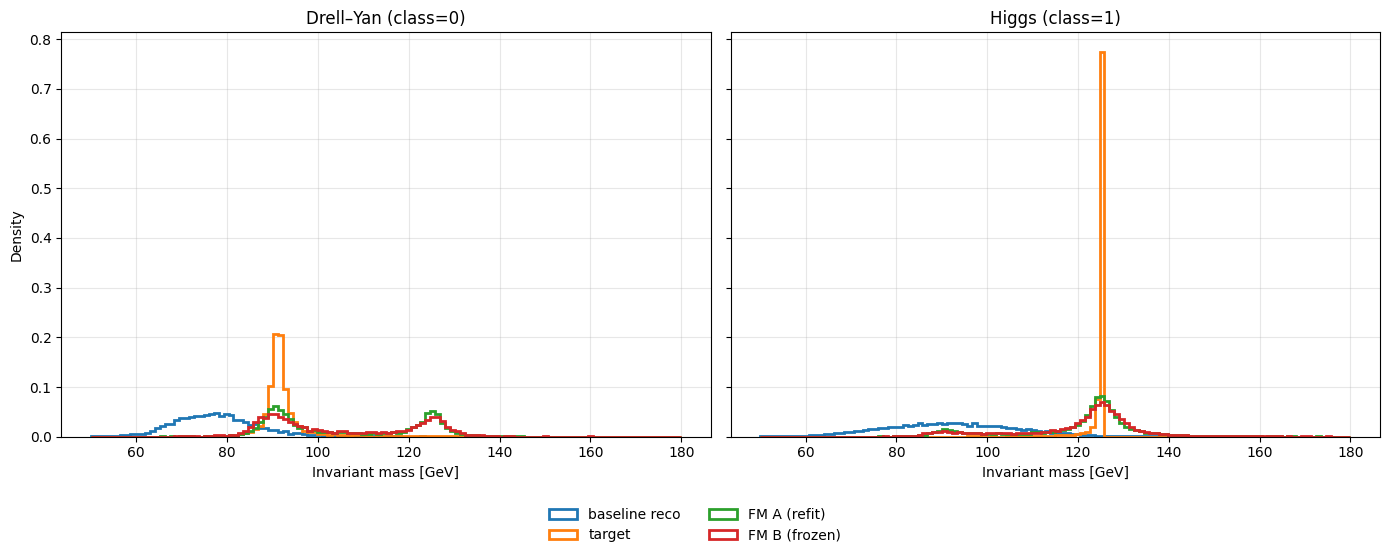

In [106]:
import matplotlib.pyplot as plt

# --- test set comune ---
df_trainA, df_valA, df_testA = res_ft_A["df_splits"]
df_test = df_testA.copy()

# --- predizioni A e massa ---
predA = predict_tau_corr(df_test, res_ft_A, train_cols, y_cols, n_steps=60)
df_test["inv_mass_FM_A"] = inv_mass_two_objects(
    df_test["tau1_pt_reco_corrPNet"] * predA["tau1_corr_pred"],
    df_test["tau1_eta"], df_test["tau1_phi"], df_test["tau1_mass"],
    df_test["tau2_pt_reco_corrPNet"] * predA["tau2_corr_pred"],
    df_test["tau2_eta"], df_test["tau2_phi"], df_test["tau2_mass"],
)

# --- predizioni B e massa (stesso df_test) ---
predB = predict_tau_corr(df_test, res_ft_B, train_cols, y_cols, n_steps=60)
df_test["inv_mass_FM_B"] = inv_mass_two_objects(
    df_test["tau1_pt_reco_corrPNet"] * predB["tau1_corr_pred"],
    df_test["tau1_eta"], df_test["tau1_phi"], df_test["tau1_mass"],
    df_test["tau2_pt_reco_corrPNet"] * predB["tau2_corr_pred"],
    df_test["tau2_eta"], df_test["tau2_phi"], df_test["tau2_mass"],
)

def plot_masses_AB_by_class(df, mass_range=(50, 180), bins=120, class_col="class"):
    df_dy = df[df[class_col]==0]
    df_h  = df[df[class_col]==1]

    fig, ax = plt.subplots(1, 2, figsize=(14,5), sharey=True)

    # DY
    ax[0].hist(df_dy["inv_mass_reco"], bins=bins, range=mass_range, histtype="step", density=True, lw=2, label="baseline reco")
    ax[0].hist(df_dy["inv_mass_tar"],  bins=bins, range=mass_range, histtype="step", density=True, lw=2, label="target")
    ax[0].hist(df_dy["inv_mass_FM_A"], bins=bins, range=mass_range, histtype="step", density=True, lw=2, label="FM A (refit)")
    ax[0].hist(df_dy["inv_mass_FM_B"], bins=bins, range=mass_range, histtype="step", density=True, lw=2, label="FM B (frozen)")
    ax[0].set_title("Drell–Yan (class=0)")
    ax[0].set_xlabel("Invariant mass [GeV]")
    ax[0].set_ylabel("Density")
    ax[0].grid(alpha=0.3)

    # Higgs
    ax[1].hist(df_h["inv_mass_reco"], bins=bins, range=mass_range, histtype="step", density=True, lw=2, label="baseline reco")
    ax[1].hist(df_h["inv_mass_tar"],  bins=bins, range=mass_range, histtype="step", density=True, lw=2, label="target")
    ax[1].hist(df_h["inv_mass_FM_A"], bins=bins, range=mass_range, histtype="step", density=True, lw=2, label="FM A (refit)")
    ax[1].hist(df_h["inv_mass_FM_B"], bins=bins, range=mass_range, histtype="step", density=True, lw=2, label="FM B (frozen)")
    ax[1].set_title("Higgs (class=1)")
    ax[1].set_xlabel("Invariant mass [GeV]")
    ax[1].grid(alpha=0.3)

  
    handles, labels = ax[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.12))

    plt.tight_layout()
    plt.show()

plot_masses_AB_by_class(df_test, mass_range=(50, 180), bins=120)

In [107]:
import pandas as pd

def compute_all_metrics(df, mass_col, label, mass_range=(50, 180), bins=120):
    # S/B (±3σ)
    sb = compute_S_over_B(df, mass_col, class_col="class", sigma_window=3.0)

    # KL + EMD (DY vs H)
    kl  = compute_KL_divergence(df, mass_col, bins=bins, mass_range=mass_range)
    emd = compute_EMD(df, mass_col)

    # MAE/RMSE (Higgs-only)
    mae, rmse = mass_mae_rmse(df, mass_col)

    return {
        "Method": label,
        "S/B (±3σ)": sb["S_over_B"],
        "KL": kl,
        "EMD": emd,
        "MAE_H [GeV]": mae,
        "RMSE_H [GeV]": rmse,
        "mu_H [GeV]": sb["mu"],
        "sigma_H [GeV]": sb["sigma"],
    }

metrics_rows = []
metrics_rows.append(compute_all_metrics(df_test, "inv_mass_reco", "Baseline reco"))
metrics_rows.append(compute_all_metrics(df_test, "inv_mass_FM_A", "FM A (refit scalers)"))
metrics_rows.append(compute_all_metrics(df_test, "inv_mass_FM_B", "FM B (frozen scalers)"))

df_metrics_AB = pd.DataFrame(metrics_rows).round(3)
df_metrics_AB

,Method,S/B (±3σ),KL,EMD,MAE_H [GeV],RMSE_H [GeV],mu_H [GeV],sigma_H [GeV]
0,Baseline reco,2.631,1.073,14.541,32.701,35.812,91.890,15.082
1,FM A (refit scalers),2.629,0.623,14.337,9.888,15.219,120.094,14.488
2,FM B (frozen scalers),2.631,0.753,14.851,10.152,15.220,120.226,14.554


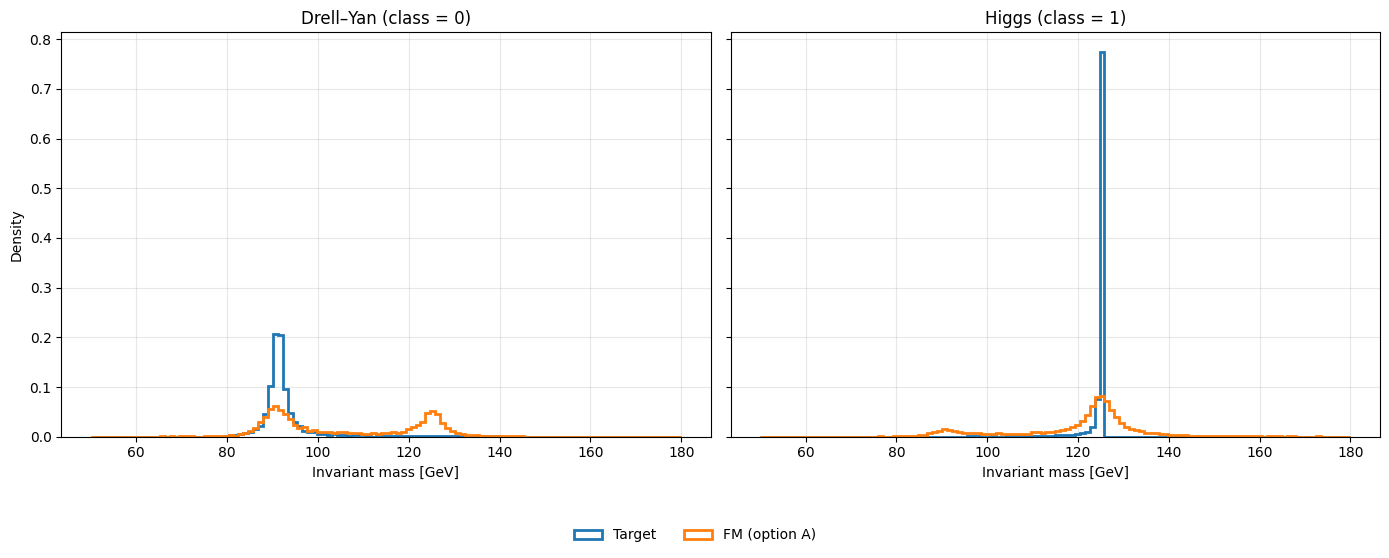

In [109]:
import matplotlib.pyplot as plt

def plot_target_vs_FM_by_class(
    df,
    mass_col_FM="inv_mass_FM_A",
    mass_col_tar="inv_mass_tar",
    class_col="class",
    mass_range=(50, 180),
    bins=120,
):
    df_dy = df[df[class_col] == 0]
    df_h  = df[df[class_col] == 1]

    fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    # --- DY ---
    ax[0].hist(
        df_dy[mass_col_tar],
        bins=bins, range=mass_range,
        histtype="step", density=True, lw=2,
        label="Target"
    )
    ax[0].hist(
        df_dy[mass_col_FM],
        bins=bins, range=mass_range,
        histtype="step", density=True, lw=2,
        label="FM (option A)"
    )
    ax[0].set_title("Drell–Yan (class = 0)")
    ax[0].set_xlabel("Invariant mass [GeV]")
    ax[0].set_ylabel("Density")
    ax[0].grid(alpha=0.3)

    # --- Higgs ---
    ax[1].hist(
        df_h[mass_col_tar],
        bins=bins, range=mass_range,
        histtype="step", density=True, lw=2,
        label="Target"
    )
    ax[1].hist(
        df_h[mass_col_FM],
        bins=bins, range=mass_range,
        histtype="step", density=True, lw=2,
        label="FM (option A)"
    )
    ax[1].set_title("Higgs (class = 1)")
    ax[1].set_xlabel("Invariant mass [GeV]")
    ax[1].grid(alpha=0.3)

    # legenda unica
    handles, labels = ax[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="lower center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, -0.12)
    )

    plt.tight_layout()
    plt.show()



plot_target_vs_FM_by_class(
    df_test,
    mass_range=(50, 180),
    bins=120,
)

In [110]:
import numpy as np
import pandas as pd
from scipy.stats import wasserstein_distance

def compute_target_metrics(
    df,
    mass_col_FM,
    mass_col_tar="inv_mass_tar",
    class_col="class",
    which_class=1,
    bins=120,
    mass_range=(50, 180),
    eps=1e-12,
):
    d = df[df[class_col] == which_class]

    m_tar = d[mass_col_tar].values
    m_fm  = d[mass_col_FM].values

    # MAE / RMSE
    err = m_fm - m_tar
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err**2))

    # KL(target || FM)
    p_tar, _ = np.histogram(m_tar, bins=bins, range=mass_range, density=True)
    p_fm,  _ = np.histogram(m_fm,  bins=bins, range=mass_range, density=True)

    p_tar = p_tar + eps
    p_fm  = p_fm  + eps
    kl = np.sum(p_tar * np.log(p_tar / p_fm))

    # EMD
    emd = wasserstein_distance(m_tar, m_fm)

    return mae, rmse, kl, emd


rows = []

for label, cls in [("DY", 0), ("Higgs", 1)]:
    mae, rmse, kl, emd = compute_target_metrics(
        df_test,
        mass_col_FM="inv_mass_FM_A",
        which_class=cls,
    )
    rows.append({
        "Class": label,
        "MAE [GeV]": mae,
        "RMSE [GeV]": rmse,
        "KL(target || FM)": kl,
        "EMD(target, FM)": emd,
    })

df_target_metrics = pd.DataFrame(rows).round(3)
df_target_metrics


,Class,MAE [GeV],RMSE [GeV],KL(target || FM),"EMD(target, FM)"
0,DY,15.701,21.087,0.587,13.273
1,Higgs,9.888,15.219,1.635,9.162


In [111]:
# Final comparison

import pandas as pd

# stesso test set: uso quello di res_unbalanced_cut (baseline DY+H)
df_train0, df_val0, df_test0 = res_unbalanced_cut["df_splits"]
df_test = df_test0.copy()

# predizioni baseline (DY+H only)
pred_base = predict_tau_corr(df_test, res_unbalanced_cut, train_cols, y_cols, n_steps=60)
df_test["inv_mass_FM_base"] = inv_mass_two_objects(
    df_test["tau1_pt_reco_corrPNet"] * pred_base["tau1_corr_pred"],
    df_test["tau1_eta"], df_test["tau1_phi"], df_test["tau1_mass"],
    df_test["tau2_pt_reco_corrPNet"] * pred_base["tau2_corr_pred"],
    df_test["tau2_eta"], df_test["tau2_phi"], df_test["tau2_mass"],
)

# predizioni fine-tuned (flat -> DY+H)
pred_ft = predict_tau_corr(df_test, res_ft_A, train_cols, y_cols, n_steps=60)
df_test["inv_mass_FM_ft"] = inv_mass_two_objects(
    df_test["tau1_pt_reco_corrPNet"] * pred_ft["tau1_corr_pred"],
    df_test["tau1_eta"], df_test["tau1_phi"], df_test["tau1_mass"],
    df_test["tau2_pt_reco_corrPNet"] * pred_ft["tau2_corr_pred"],
    df_test["tau2_eta"], df_test["tau2_phi"], df_test["tau2_mass"],
)

df_test[["inv_mass_tar", "inv_mass_FM_base", "inv_mass_FM_ft", "class"]].head()

,inv_mass_tar,inv_mass_FM_base,inv_mass_FM_ft,class
0,91.865789,93.829247,91.805095,0
1,124.910946,116.786969,128.593935,1
2,92.094251,116.632943,86.607328,0
3,87.643230,119.681957,113.914061,0
4,124.933986,127.149679,121.652617,1


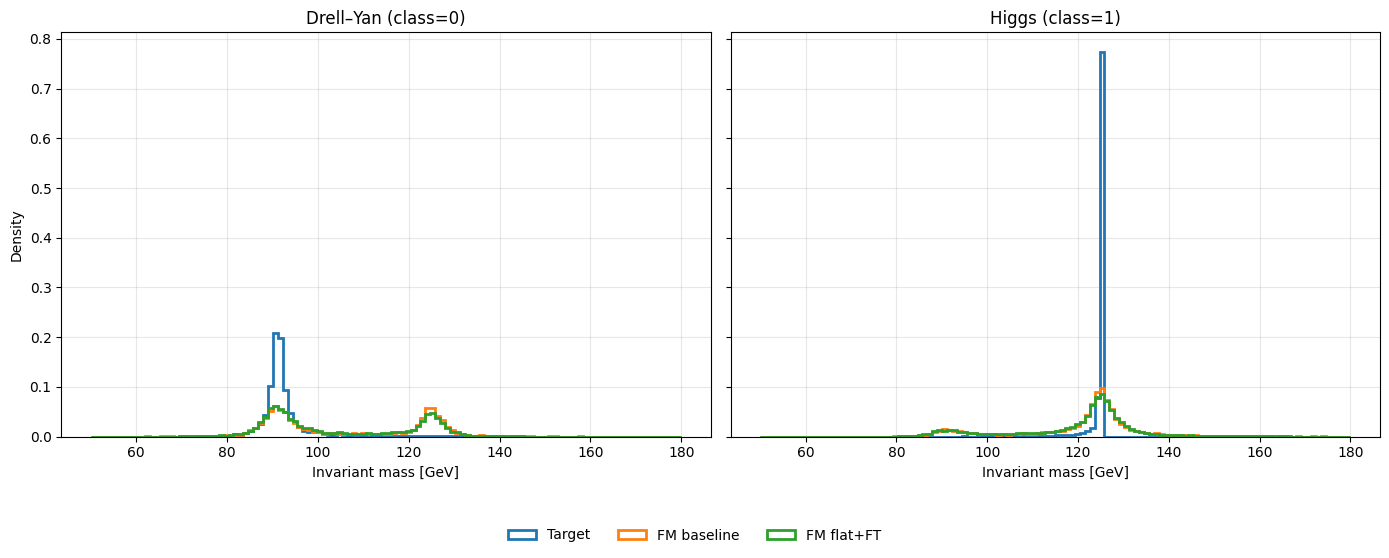

In [112]:
import matplotlib.pyplot as plt

def plot_target_vs_two_models_by_class(df, tar="inv_mass_tar", m1="inv_mass_FM_base", m2="inv_mass_FM_ft",
                                       labels=("FM baseline", "FM flat+FT"),
                                       mass_range=(50,180), bins=120, class_col="class"):
    df_dy = df[df[class_col]==0]
    df_h  = df[df[class_col]==1]

    fig, ax = plt.subplots(1,2, figsize=(14,5), sharey=True)

    # DY
    ax[0].hist(df_dy[tar], bins=bins, range=mass_range, histtype="step", density=True, lw=2, label="Target")
    ax[0].hist(df_dy[m1],  bins=bins, range=mass_range, histtype="step", density=True, lw=2, label=labels[0])
    ax[0].hist(df_dy[m2],  bins=bins, range=mass_range, histtype="step", density=True, lw=2, label=labels[1])
    ax[0].set_title("Drell–Yan (class=0)")
    ax[0].set_xlabel("Invariant mass [GeV]")
    ax[0].set_ylabel("Density")
    ax[0].grid(alpha=0.3)

    # H
    ax[1].hist(df_h[tar], bins=bins, range=mass_range, histtype="step", density=True, lw=2, label="Target")
    ax[1].hist(df_h[m1],  bins=bins, range=mass_range, histtype="step", density=True, lw=2, label=labels[0])
    ax[1].hist(df_h[m2],  bins=bins, range=mass_range, histtype="step", density=True, lw=2, label=labels[1])
    ax[1].set_title("Higgs (class=1)")
    ax[1].set_xlabel("Invariant mass [GeV]")
    ax[1].grid(alpha=0.3)

    handles, labs = ax[0].get_legend_handles_labels()
    fig.legend(handles, labs, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.12))
    plt.tight_layout()
    plt.show()

plot_target_vs_two_models_by_class(df_test)


In [113]:
import numpy as np
from scipy.stats import wasserstein_distance

def target_metrics_per_class(df, mass_col, tar="inv_mass_tar", class_col="class", which_class=1,
                             bins=120, mass_range=(50,180), eps=1e-12):
    d = df[df[class_col]==which_class]
    m_tar = d[tar].values
    m_mod = d[mass_col].values

    err = m_mod - m_tar
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err**2))

    p_tar, _ = np.histogram(m_tar, bins=bins, range=mass_range, density=True)
    p_mod, _ = np.histogram(m_mod, bins=bins, range=mass_range, density=True)

    p_tar = p_tar + eps
    p_mod = p_mod + eps
    kl = np.sum(p_tar * np.log(p_tar / p_mod))

    emd = wasserstein_distance(m_tar, m_mod)

    return mae, rmse, kl, emd

rows = []
for model_name, col in [("FM baseline (DY+H only)", "inv_mass_FM_base"),
                        ("FM flat pretrain + FT", "inv_mass_FM_ft")]:
    for label, cls in [("DY",0), ("Higgs",1)]:
        mae, rmse, kl, emd = target_metrics_per_class(df_test, col, which_class=cls)
        rows.append({
            "Model": model_name,
            "Class": label,
            "MAE [GeV]": mae,
            "RMSE [GeV]": rmse,
            "KL(target||model)": kl,
            "EMD(target,model)": emd
        })

df_compare = pd.DataFrame(rows).round(3)
df_compare


,Model,Class,MAE [GeV],RMSE [GeV],KL(target||model),"EMD(target,model)"
0,FM baseline (DY+H only),DY,16.253,21.763,0.577,13.609
1,FM baseline (DY+H only),Higgs,9.555,14.954,1.492,8.875
2,FM flat pretrain + FT,DY,14.960,20.402,0.535,12.182
3,FM flat pretrain + FT,Higgs,9.864,15.149,1.601,9.170


- To sum up:
  1. Higgs: il fine-tuning non migliora sensibilmente ma non peggiora
  2. DY: il flat pretraining aiuta la stabilità globale e migliora il background